<a href="https://colab.research.google.com/github/gvspavan15-de/march_2026/blob/main/Copy_of_ASSIGNMENT_MARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Replace 'path/to/your/dataset.csv' with the actual path to your CSV file
df = pd.read_csv('customer_churn_prediction_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


TASK-1

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Display data types and non-null counts to identify potential issues (e.g., 'TotalCharges' as object)
print("\nDataFrame Info:\n")
df.info()

Missing values in each column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        300 non-null    object 
 1   gender            300 non-null    object 
 2   SeniorCitizen     300 non-null    int64  
 3   Partner           300 non-null    object 
 4   Dependents        300 non-null    object 
 5   tenure            300 non-null    in

In [ ]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Impute missing 'TotalCharges' with 0 (assuming new customers with no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify no more missing values in 'TotalCharges'
print("Missing values after handling TotalCharges:\n", df.isnull().sum().loc['TotalCharges'])

# Confirm data type conversion
print("\nData type of TotalCharges after conversion:", df['TotalCharges'].dtype)

Missing values after handling TotalCharges:
 0

Data type of TotalCharges after conversion: float64


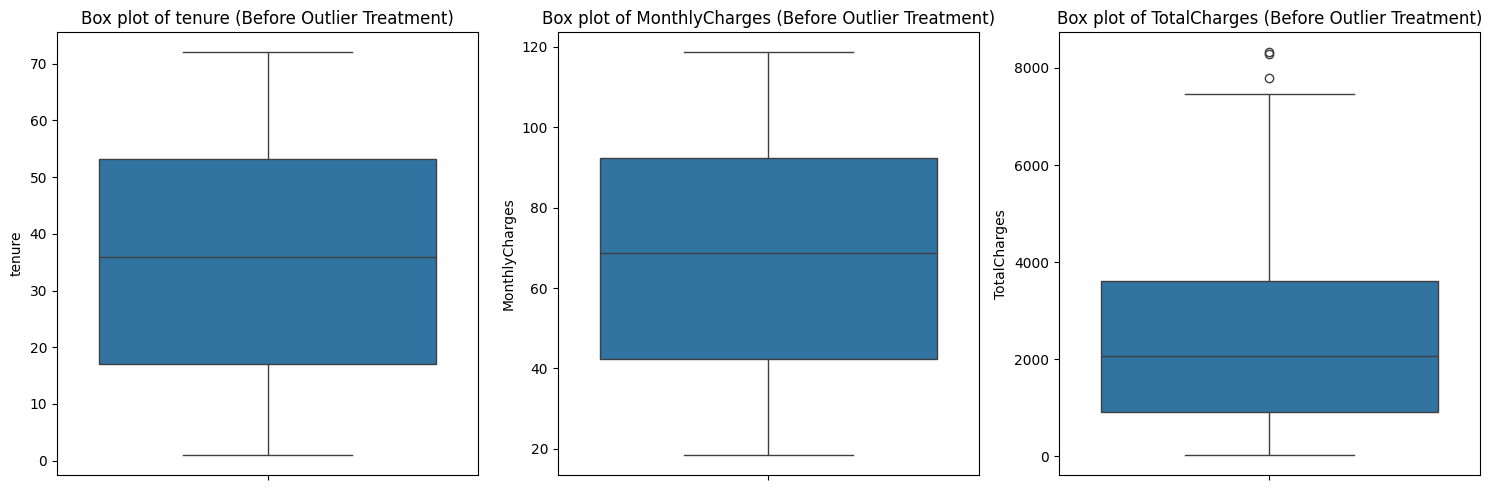

Outliers treated for:  ['tenure', 'MonthlyCharges', 'TotalCharges']


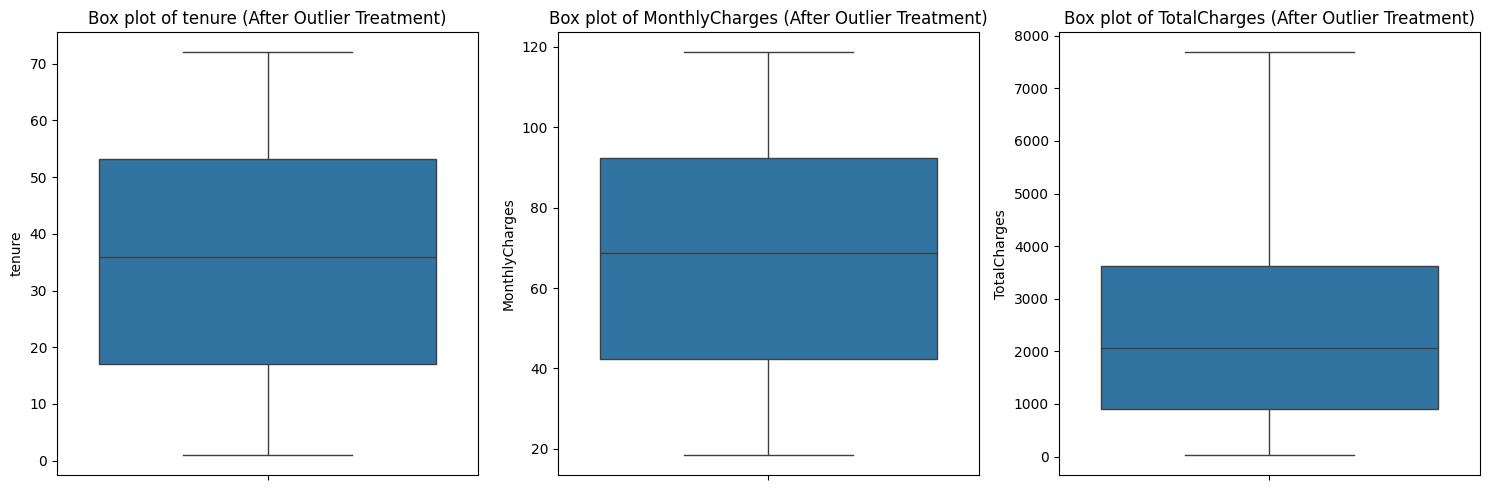

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create box plots before outlier treatment
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col} (Before Outlier Treatment)')
plt.tight_layout()
plt.show()

# Function to detect and treat outliers using IQR
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

# Apply outlier treatment
for col in numerical_cols:
    df = cap_outliers_iqr(df, col)

print("Outliers treated for: ", numerical_cols)

# Create box plots after outlier treatment
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col} (After Outlier Treatment)')
plt.tight_layout()
plt.show()

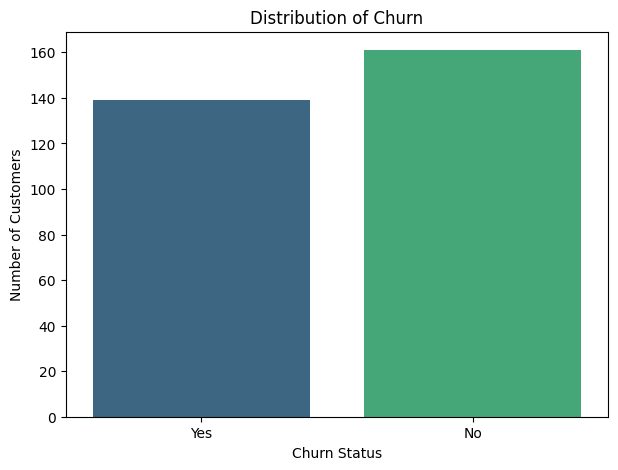


Percentage distribution of Churn:
 Churn
No     53.666667
Yes    46.333333
Name: proportion, dtype: float64


In [ ]:
# Analyze class imbalance in the 'Churn' column
plt.figure(figsize=(7, 5))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Distribution of Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

churn_distribution = df['Churn'].value_counts(normalize=True) * 100
print("\nPercentage distribution of Churn:\n", churn_distribution)

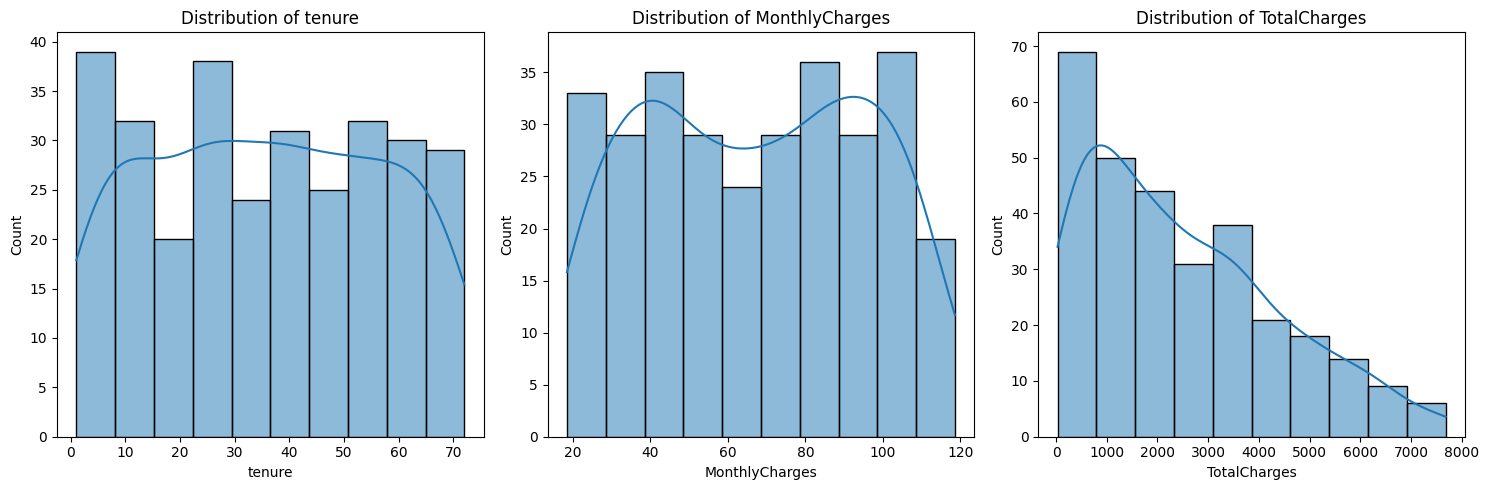

In [ ]:
# Histograms for numerical features
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Box plots for numerical features (already done during outlier treatment, but can be revisited if needed)
# For brevity, we'll skip re-plotting box plots here as they were used for outlier visualization.
# If a separate, cleaner view without outlier emphasis is desired, they can be plotted again.

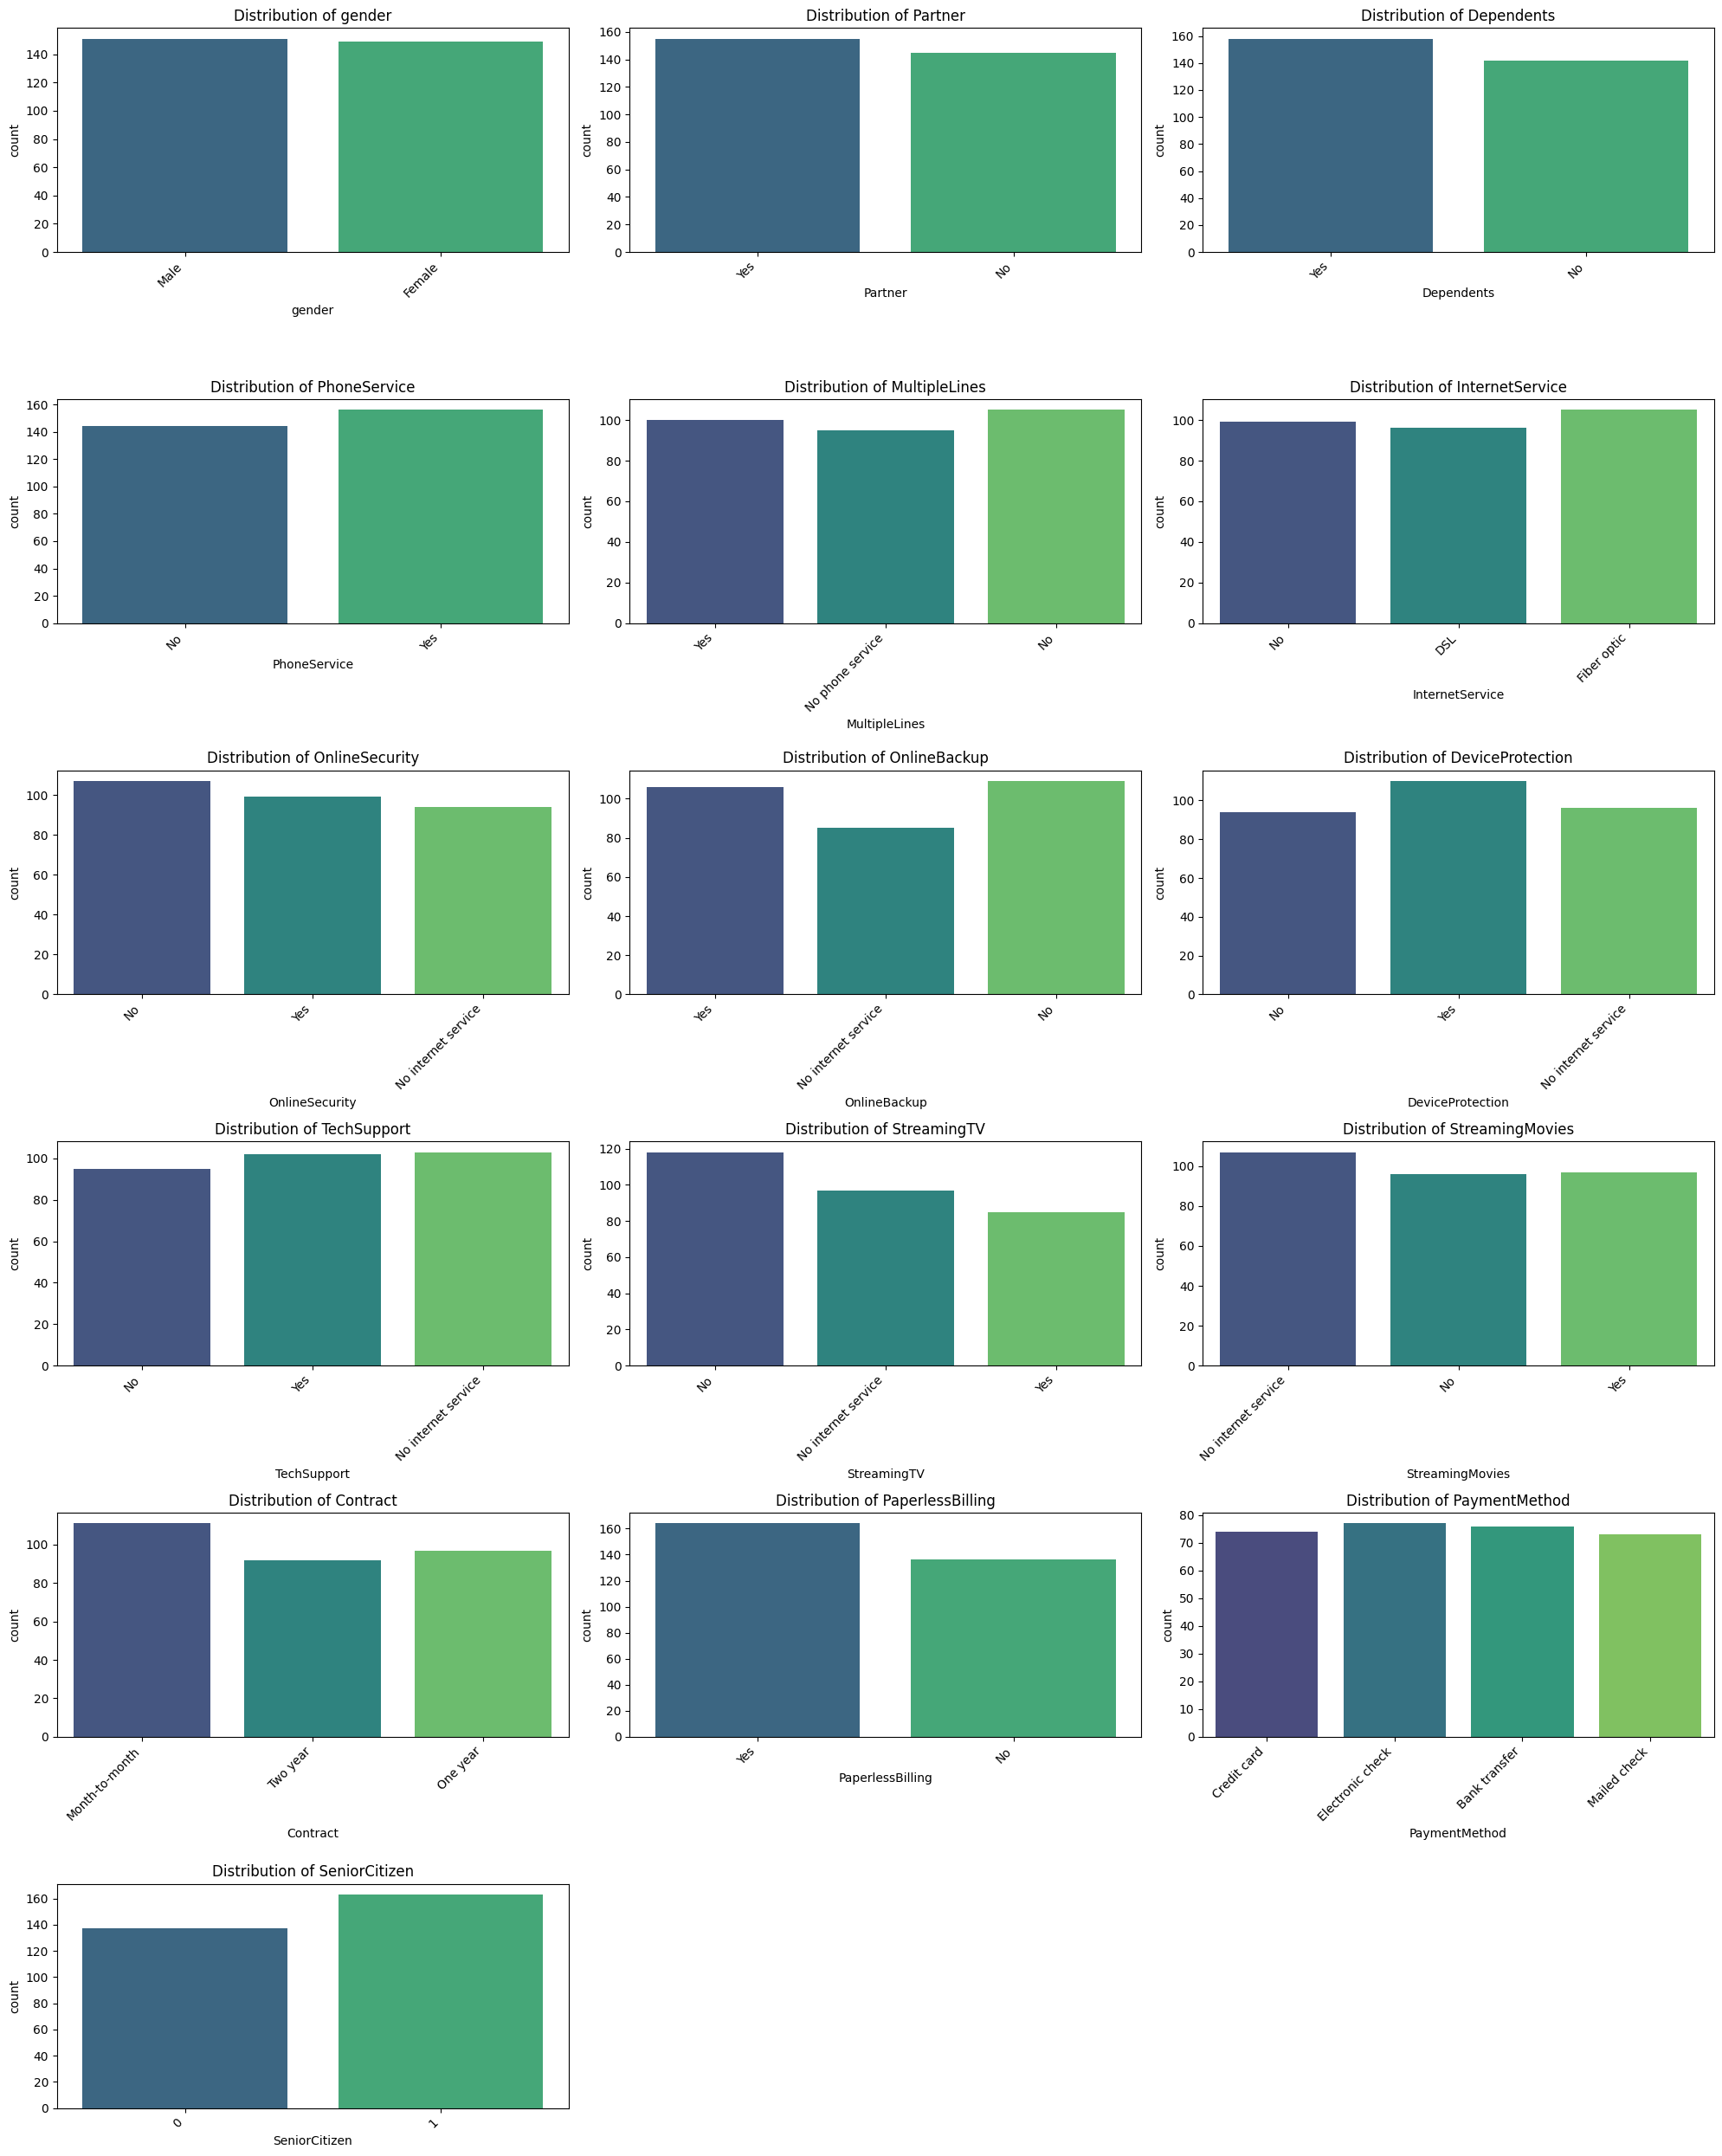

In [ ]:
# Identify categorical columns (excluding 'customerID' and 'Churn' for now as Churn is target)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['customerID', 'Churn']]

# Add 'SeniorCitizen' as a categorical feature for distribution analysis
categorical_cols.append('SeniorCitizen')


# Create count plots for categorical features
plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(6, 3, i + 1) # Adjust subplot grid based on number of categorical features
    sns.countplot(x=col, data=df, palette='viridis', hue=col, legend=False) # Fixed: added hue=col and legend=False
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

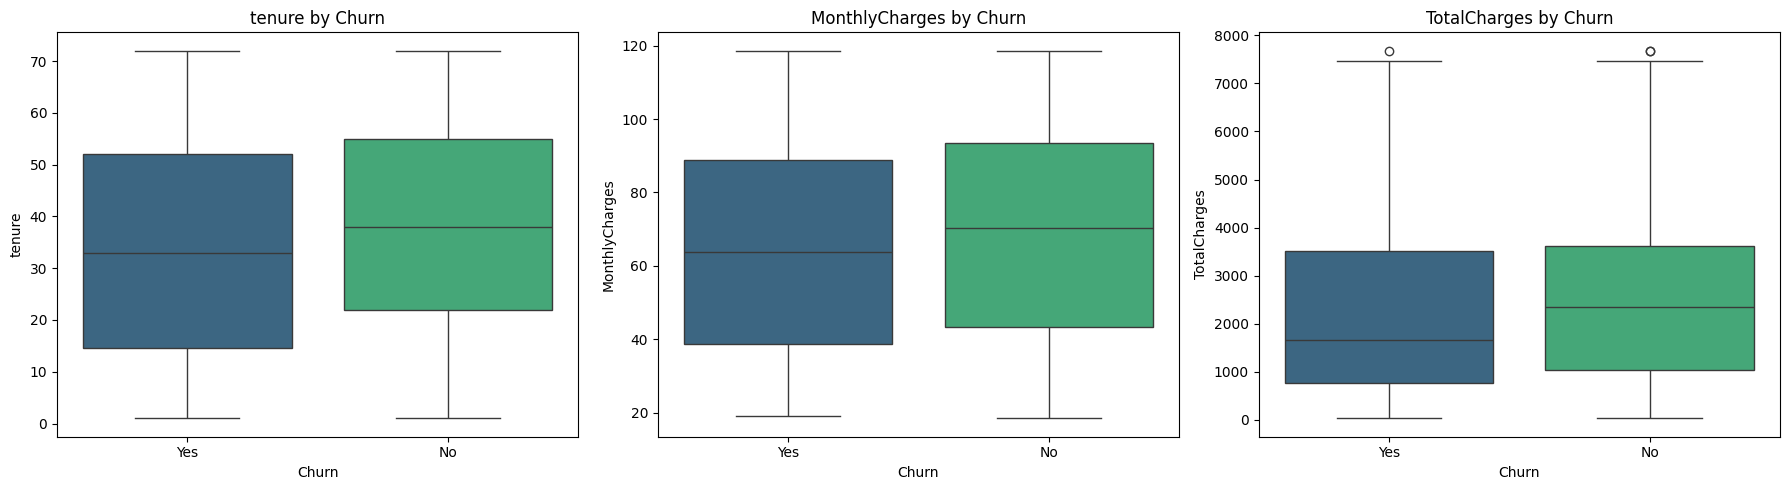

In [ ]:
plt.figure(figsize=(18, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='Churn', y=col, data=df, palette='viridis', hue='Churn', legend=False)
    plt.title(f'{col} by Churn')
plt.tight_layout()
plt.show()

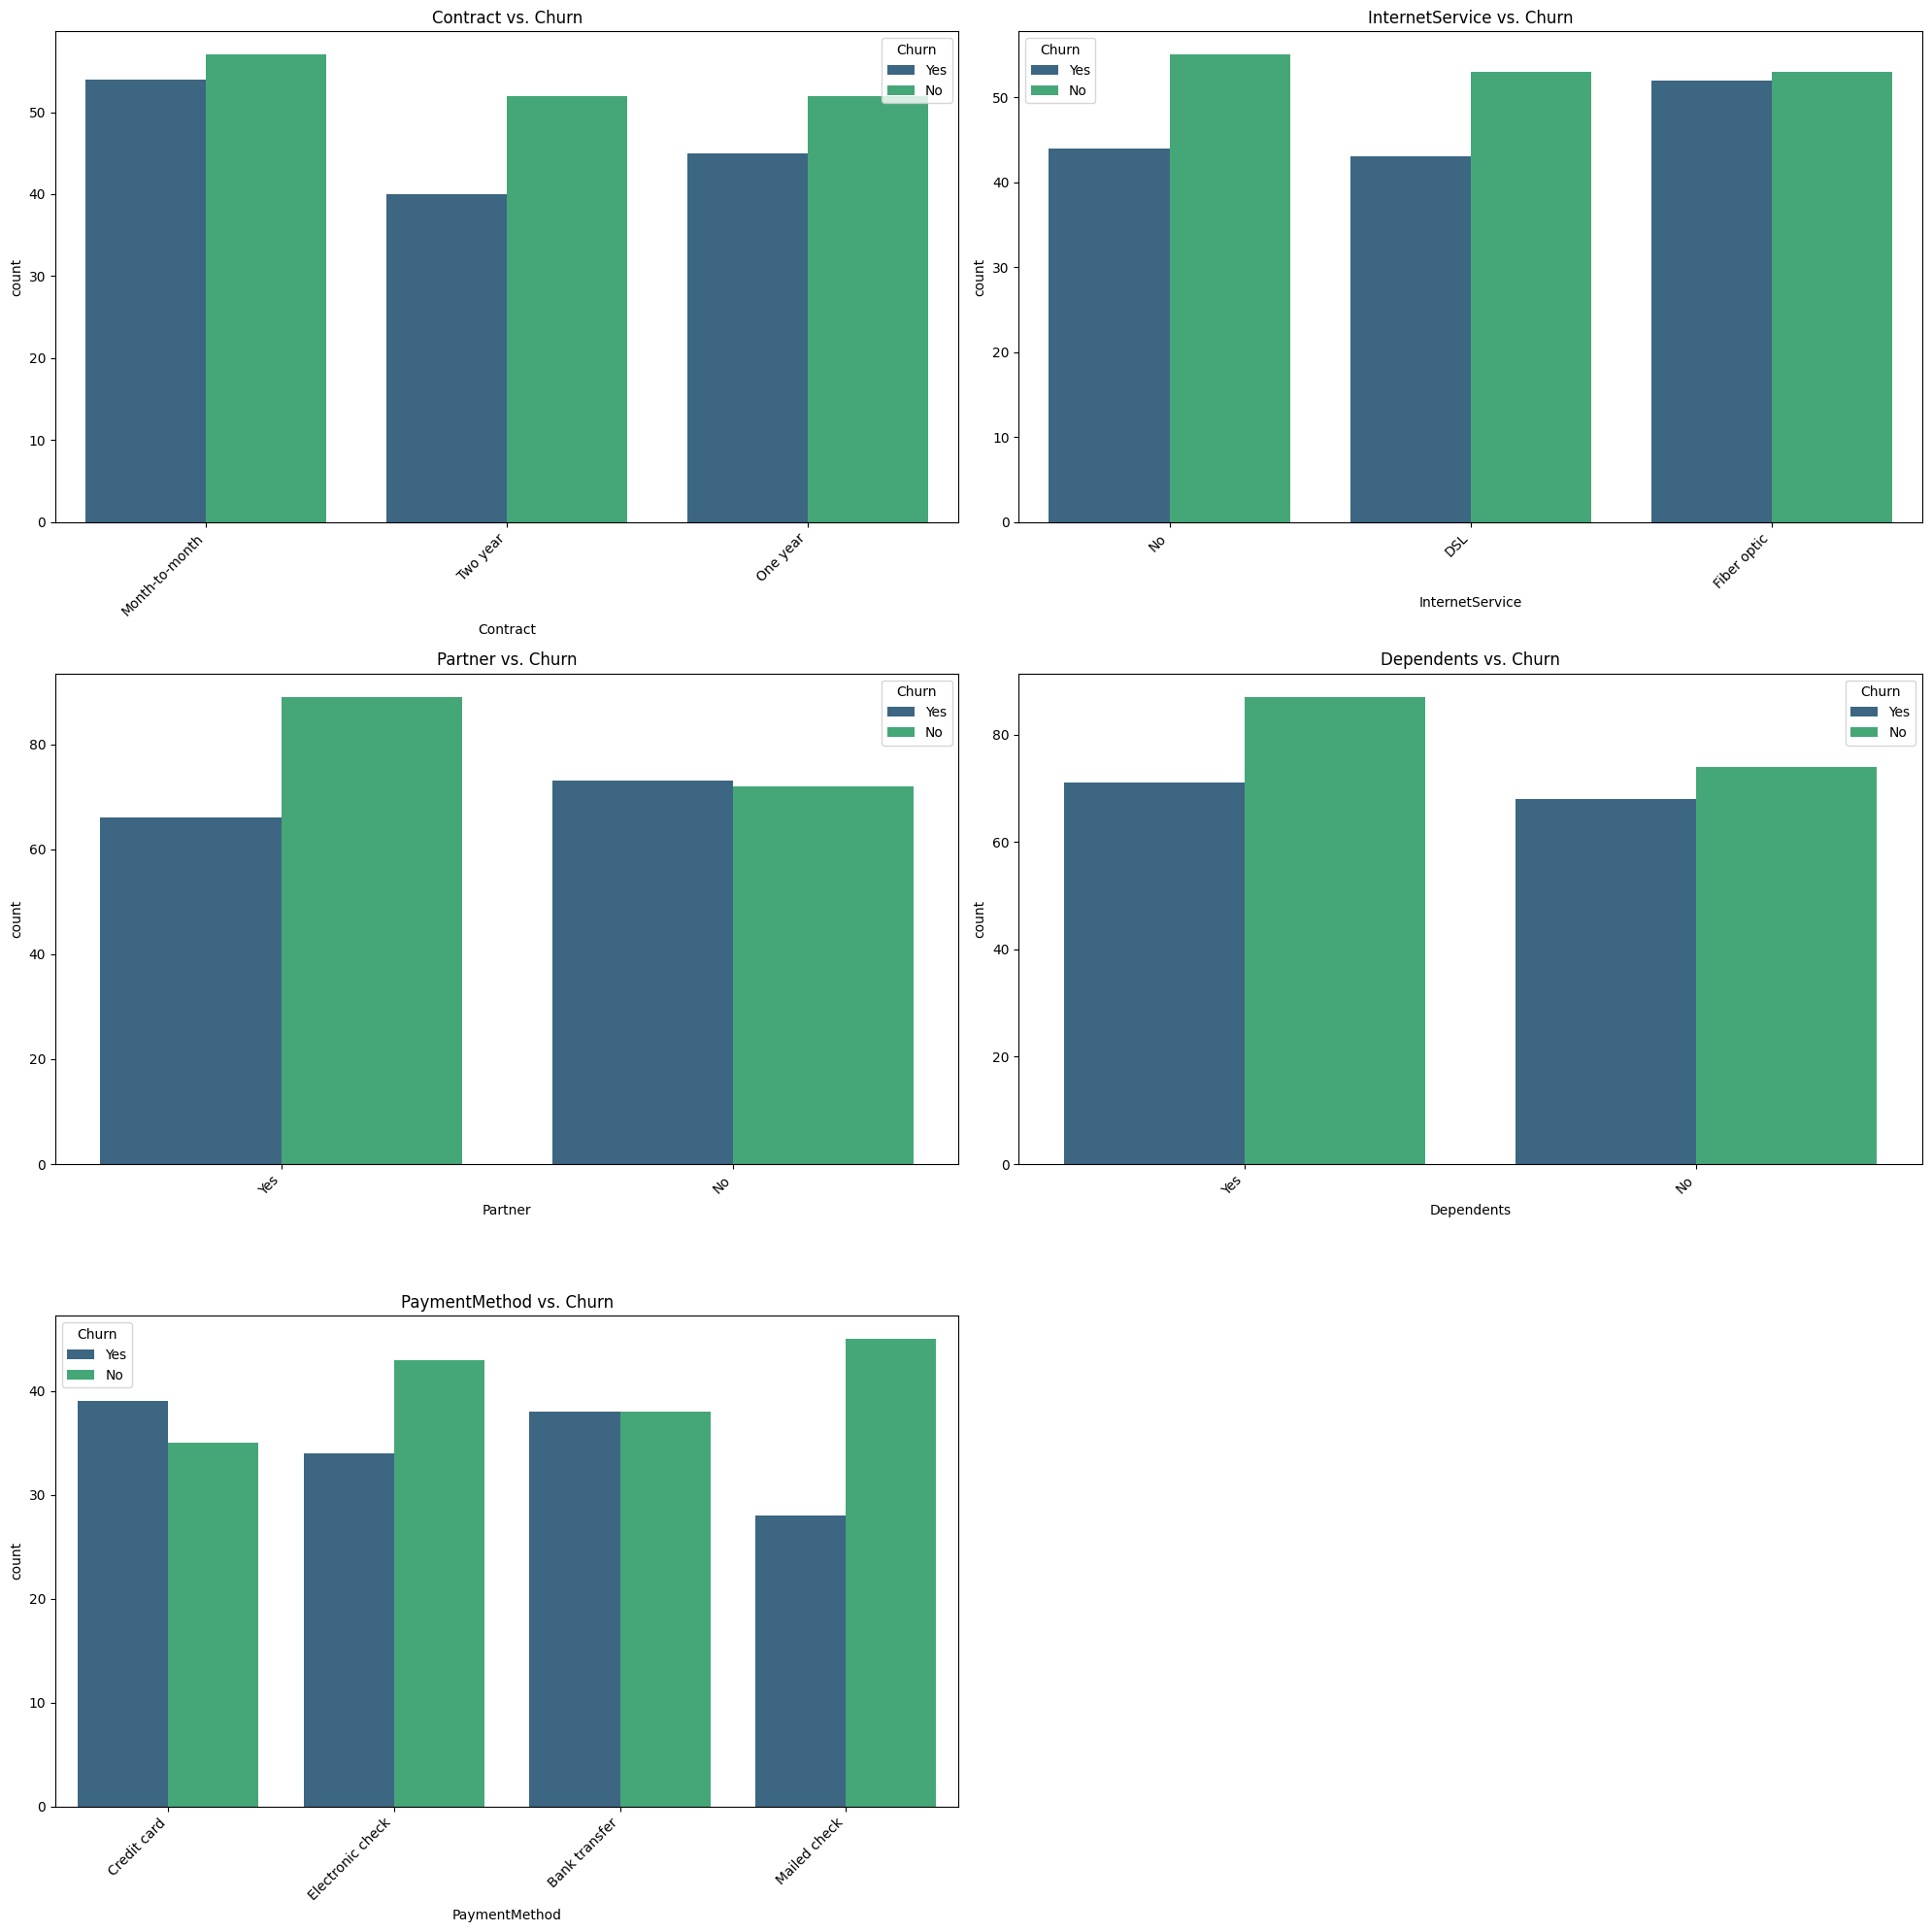

In [ ]:
selected_categorical_for_bivariate = ['Contract', 'InternetService', 'Partner', 'Dependents', 'PaymentMethod']

plt.figure(figsize=(20, 20))
for i, col in enumerate(selected_categorical_for_bivariate):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid based on number of selected features
    sns.countplot(x=col, hue='Churn', data=df, palette='viridis')
    plt.title(f'{col} vs. Churn')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

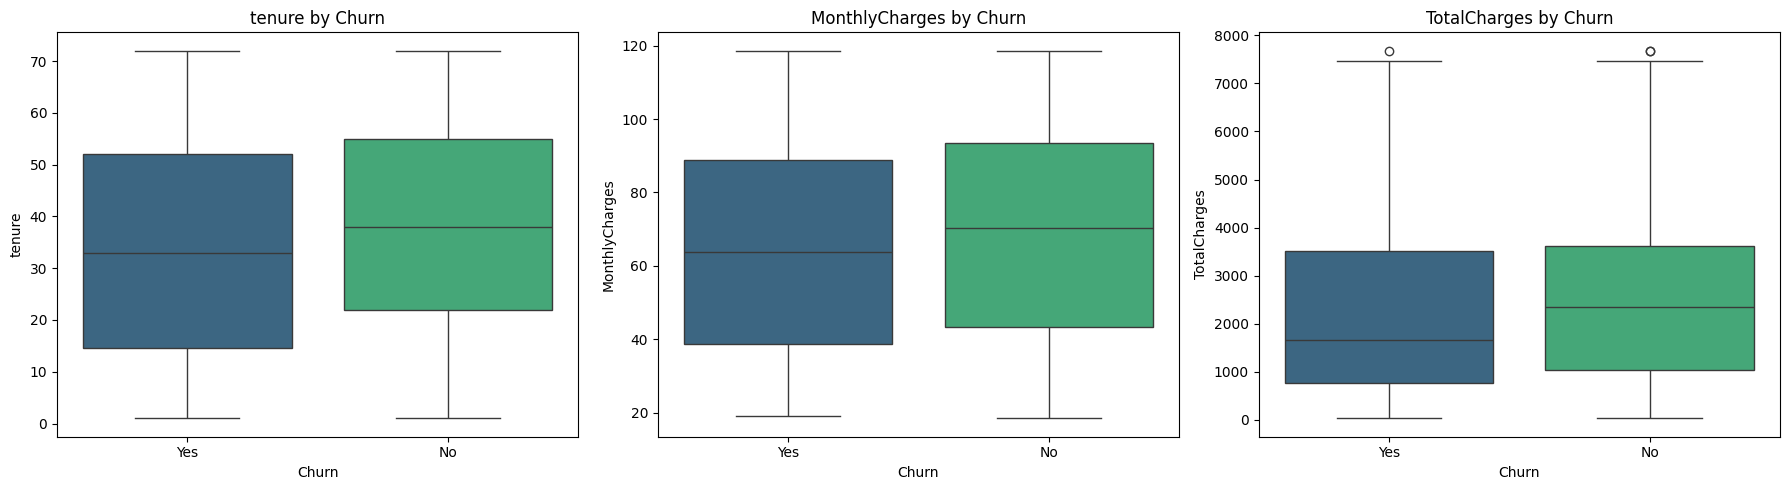

In [ ]:
plt.figure(figsize=(18, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='Churn', y=col, data=df, palette='viridis', hue='Churn', legend=False)
    plt.title(f'{col} by Churn')
plt.tight_layout()
plt.show()

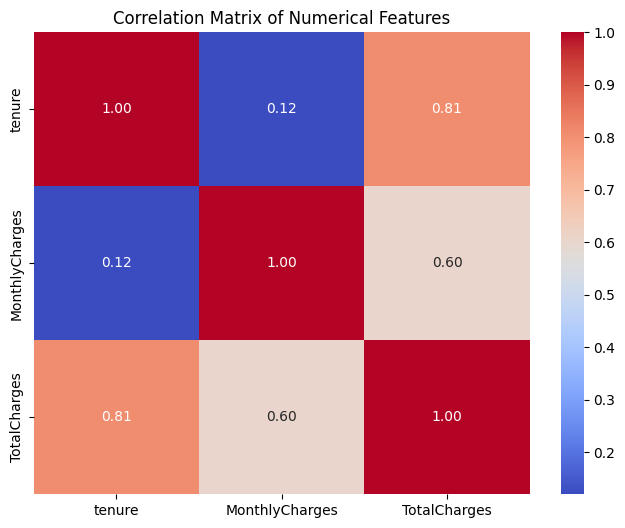

In [ ]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

TASK-2


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Create a copy of the DataFrame to avoid modifying the original 'df' in place
df_encoded = df.copy()

# Separate target variable 'Churn' for Label Encoding
# It's a binary categorical feature
le_churn = LabelEncoder()
df_encoded['Churn'] = le_churn.fit_transform(df_encoded['Churn'])

print("Encoded 'Churn' column:")
print(df_encoded['Churn'].value_counts())
print("Mapping for Churn: ", list(le_churn.classes_), "->", list(range(len(le_churn.classes_))))

# Identify binary and multi-category object columns (excluding 'customerID')
binary_cols = [
    col for col in df_encoded.select_dtypes(include='object').columns
    if df_encoded[col].nunique() == 2 and col != 'customerID'
]
multi_category_cols = [
    col for col in df_encoded.select_dtypes(include='object').columns
    if df_encoded[col].nunique() > 2 and col != 'customerID'
]

print(f"\nBinary categorical columns for Label Encoding: {binary_cols}")
print(f"Multi-category columns for One-Hot Encoding: {multi_category_cols}")

# Apply Label Encoding to binary columns
for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Mapping for {col}: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

# Apply One-Hot Encoding to multi-category columns
# handle_unknown='ignore' prevents errors if a new category appears during testing
# drop='first' avoids multicollinearity by dropping the first category
oh_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

# Fit and transform the selected columns
oh_encoded_features = oh_encoder.fit_transform(df_encoded[multi_category_cols])

# Create a DataFrame from the one-hot encoded features
oh_encoded_df = pd.DataFrame(
    oh_encoded_features,
    columns=oh_encoder.get_feature_names_out(multi_category_cols),
    index=df_encoded.index
)

# Drop original multi-category columns and concatenate one-hot encoded ones
df_encoded = df_encoded.drop(columns=multi_category_cols)
df_encoded = pd.concat([df_encoded, oh_encoded_df], axis=1)

print("\nDataFrame after encoding categorical variables:")
display(df_encoded.head())

Encoded 'Churn' column:
Churn
0    161
1    139
Name: count, dtype: int64
Mapping for Churn:  ['No', 'Yes'] -> [0, 1]

Binary categorical columns for Label Encoding: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category columns for One-Hot Encoding: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Mapping for gender: ['Female', 'Male'] -> [0, 1]
Mapping for Partner: ['No', 'Yes'] -> [0, 1]
Mapping for Dependents: ['No', 'Yes'] -> [0, 1]
Mapping for PhoneService: ['No', 'Yes'] -> [0, 1]
Mapping for PaperlessBilling: ['No', 'Yes'] -> [0, 1]

DataFrame after encoding categorical variables:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0001-XXXX,1,0,1,1,5.0,0,1,27.43,137.15,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0002-XXXX,0,0,0,0,42.0,1,0,38.28,1607.76,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0003-XXXX,1,0,0,0,61.0,1,0,106.44,6492.84,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0004-XXXX,1,1,0,1,22.0,1,0,92.49,2034.78,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0005-XXXX,1,1,1,1,21.0,0,0,19.63,412.23,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
# 1. AvgMonthlySpend = TotalCharges / tenure
# Handle cases where tenure might be 0 to avoid division by zero
df_encoded['AvgMonthlySpend'] = df_encoded.apply(
    lambda row: row['TotalCharges'] / row['tenure'] if row['tenure'] > 0 else 0,
    axis=1
)

# 2. ServiceCount = count of subscribed services
# Identify service-related columns (e.g., OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies)
service_cols = [
    'OnlineSecurity_No internet service', # Include both for correct sum
    'OnlineSecurity_Yes',
    'OnlineBackup_No internet service',
    'OnlineBackup_Yes',
    'DeviceProtection_No internet service',
    'DeviceProtection_Yes',
    'TechSupport_No internet service',
    'TechSupport_Yes',
    'StreamingTV_No internet service',
    'StreamingTV_Yes',
    'StreamingMovies_No internet service',
    'StreamingMovies_Yes',
    'PhoneService',
    'MultipleLines_Yes' # Assuming 'No phone service' is 0 when encoded
]

# Filter to only include columns that exist in the dataframe after one-hot encoding
existing_service_cols = [col for col in service_cols if col in df_encoded.columns]

# Sum up the 'Yes' or '1' values for services. 'No internet service' should be 0.
# We need to be careful with how OneHotEncoder created these. It typically drops one category.
# Let's revisit and assume that if the 'Yes' column is 1, a service is active.
# For 'PhoneService' and 'MultipleLines_Yes' (binary encoded), 1 means active.

# Simplified approach: Sum up features that represent a 'Yes' or 'active' state for services.
# The binary encoded columns (1 for Yes, 0 for No) and one-hot encoded '_Yes' columns

service_related_features = [
    'PhoneService',
    'MultipleLines_No phone service', 'MultipleLines_Yes',
    'InternetService_Fiber optic', 'InternetService_No',
    'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
    'OnlineBackup_No internet service', 'OnlineBackup_Yes',
    'DeviceProtection_No internet service', 'DeviceProtection_Yes',
    'TechSupport_No internet service', 'TechSupport_Yes',
    'StreamingTV_No internet service', 'StreamingTV_Yes',
    'StreamingMovies_No internet service', 'StreamingMovies_Yes'
]

# Select only the columns that actually indicate a 'service' being active.
# After one-hot encoding with drop='first', the 'No' or 'No internet service' categories are often implicit.
# So, 'OnlineSecurity_Yes' being 1 means the service is active.

active_service_indicators = [
    'PhoneService',
    'MultipleLines_Yes',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

# Filter to only include columns that exist in the dataframe after one-hot encoding and label encoding
existing_active_service_indicators = [col for col in active_service_indicators if col in df_encoded.columns]

df_encoded['ServiceCount'] = df_encoded[existing_active_service_indicators].sum(axis=1)


# 3. TenureGroup: 'New' (0-12 months), 'Mid' (13-48 months), 'Long-term' (49+ months)
def get_tenure_group(tenure):
    if tenure <= 12:
        return 'New'
    elif 13 <= tenure <= 48:
        return 'Mid'
    else:
        return 'Long-term'

df_encoded['TenureGroup'] = df_encoded['tenure'].apply(get_tenure_group)

# One-Hot Encode the new 'TenureGroup' feature as it's categorical
oh_encoder_tenure_group = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
oh_encoded_tenure_group = oh_encoder_tenure_group.fit_transform(df_encoded[['TenureGroup']])
oh_encoded_tenure_group_df = pd.DataFrame(
    oh_encoded_tenure_group,
    columns=oh_encoder_tenure_group.get_feature_names_out(['TenureGroup']),
    index=df_encoded.index
)

df_encoded = df_encoded.drop(columns=['TenureGroup'])
df_encoded = pd.concat([df_encoded, oh_encoded_tenure_group_df], axis=1)

print("\nDataFrame after adding derived features:")
display(df_encoded.head())


DataFrame after adding derived features:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,TenureGroup_Mid,TenureGroup_New
0,0001-XXXX,1,0,1,1,5.0,0,1,27.43,137.15,...,0.0,0.0,0.0,1.0,0.0,0.0,27.43,2.0,0.0,1.0
1,0002-XXXX,0,0,0,0,42.0,1,0,38.28,1607.76,...,0.0,0.0,1.0,0.0,1.0,0.0,38.28,3.0,1.0,0.0
2,0003-XXXX,1,0,0,0,61.0,1,0,106.44,6492.84,...,0.0,1.0,0.0,0.0,0.0,0.0,106.44,4.0,0.0,0.0
3,0004-XXXX,1,1,0,1,22.0,1,0,92.49,2034.78,...,1.0,0.0,0.0,0.0,1.0,0.0,92.49,3.0,1.0,0.0
4,0005-XXXX,1,1,1,1,21.0,0,0,19.63,412.23,...,0.0,1.0,0.0,0.0,0.0,0.0,19.63,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify numerical columns for scaling (excluding customerID and Churn)
# Also exclude one-hot encoded and label encoded binary columns if they are not truly numerical

# Let's re-identify numerical columns from the original df to make sure we get continuous ones
original_numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Add the newly created numerical feature AvgMonthlySpend
scaling_cols = original_numerical_cols + ['AvgMonthlySpend']

# Initialize Scalers
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# Create copies for each scaling method to compare results if needed
df_scaled_standard = df_encoded.copy()
df_scaled_minmax = df_encoded.copy()

# Apply StandardScaler
df_scaled_standard[scaling_cols] = scaler_standard.fit_transform(df_scaled_standard[scaling_cols])
print("\nDataFrame after Standard Scaling (first 5 rows of scaled numerical columns):")
display(df_scaled_standard[scaling_cols].head())

# Apply MinMaxScaler
df_scaled_minmax[scaling_cols] = scaler_minmax.fit_transform(df_scaled_minmax[scaling_cols])
print("\nDataFrame after Min-Max Scaling (first 5 rows of scaled numerical columns):")
display(df_scaled_minmax[scaling_cols].head())

# For the next steps, let's proceed with the Standard Scaled DataFrame for consistency
df_final = df_scaled_standard.copy()
print("\nUsing Standard Scaled DataFrame (df_final) for subsequent steps.")


DataFrame after Standard Scaling (first 5 rows of scaled numerical columns):


,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
0,-1.460436,-1.391968,-1.228137,-1.394631
1,0.294934,-1.012469,-0.455072,-1.013797
2,1.196340,1.371556,2.112898,1.378616
3,-0.653915,0.883628,-0.230598,0.888972
4,-0.701357,-1.664788,-1.083534,-1.668411



DataFrame after Min-Max Scaling (first 5 rows of scaled numerical columns):


,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
0,0.056338,0.089630,0.014002,0.089630
1,0.577465,0.197924,0.206225,0.197924
2,0.845070,0.878231,0.844753,0.878231
3,0.295775,0.738996,0.262041,0.738996
4,0.281690,0.011778,0.049957,0.011778



Using Standard Scaled DataFrame (df_final) for subsequent steps.


TASK-3

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_final.drop(columns=['customerID', 'Churn'])
y = df_final['Churn']

# First split: 70% train, 30% temporary (for validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 15% validation, 15% test from the 30% temporary set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Verify stratification
print("\nChurn distribution in original data:\n", y.value_counts(normalize=True))
print("Churn distribution in training set:\n", y_train.value_counts(normalize=True))
print("Churn distribution in validation set:\n", y_val.value_counts(normalize=True))
print("Churn distribution in test set:\n", y_test.value_counts(normalize=True))

Shape of X_train: (210, 34)
Shape of y_train: (210,)
Shape of X_val: (45, 34)
Shape of y_val: (45,)
Shape of X_test: (45, 34)
Shape of y_test: (45,)

Churn distribution in original data:
 Churn
0    0.536667
1    0.463333
Name: proportion, dtype: float64
Churn distribution in training set:
 Churn
0    0.538095
1    0.461905
Name: proportion, dtype: float64
Churn distribution in validation set:
 Churn
0    0.533333
1    0.466667
Name: proportion, dtype: float64
Churn distribution in test set:
 Churn
0    0.533333
1    0.466667
Name: proportion, dtype: float64



--- Training Logistic Regression ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'C': 0.001, 'penalty': 'l2'}
Accuracy: 0.5333
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC Score: 0.5258
Training Time: 0.6540 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


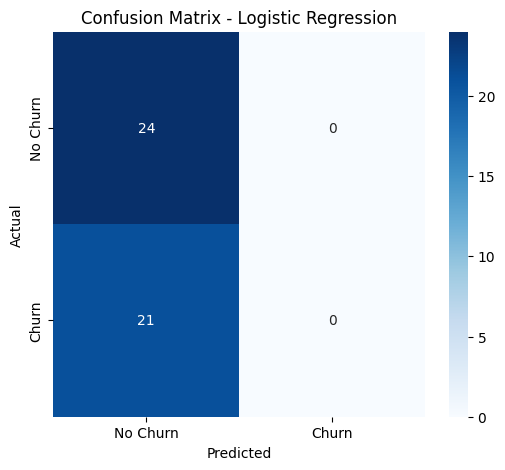

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Dictionary to store results for comparison
model_results = {}
roc_curves = {}

# --- Logistic Regression ---
print("\n--- Training Logistic Regression ---")
start_time = time.time()

# Define the model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for small datasets and L1/L2 regularization

# Define the parameter grid for GridSearchCV
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Initialize GridSearchCV
grid_search_log_reg = GridSearchCV(
    log_reg,
    param_grid_log_reg,
    cv=5, # 5-fold cross-validation on the training data
    scoring='roc_auc',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the training data (X_train, y_train)
grid_search_log_reg.fit(X_train, y_train)

# Get the best estimator
best_log_reg = grid_search_log_reg.best_estimator_

# Predict on the test set
y_pred_log_reg = best_log_reg.predict(X_test)
y_proba_log_reg = best_log_reg.predict_proba(X_test)[:, 1] # Probability of the positive class (Churn = 1)

end_time = time.time()
training_time_log_reg = end_time - start_time

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_proba_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Store results
model_results['Logistic Regression'] = {
    'Accuracy': accuracy_log_reg,
    'Precision': precision_log_reg,
    'Recall': recall_log_reg,
    'F1-Score': f1_log_reg,
    'ROC-AUC': roc_auc_log_reg,
    'Training Time': training_time_log_reg
}

# Store ROC curve data
fpr, tpr, _ = roc_curve(y_test, y_proba_log_reg)
roc_curves['Logistic Regression'] = {'fpr': fpr, 'tpr': tpr}

# Print results
print(f"Best Parameters: {grid_search_log_reg.best_params_}")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC-AUC Score: {roc_auc_log_reg:.4f}")
print(f"Training Time: {training_time_log_reg:.4f} seconds")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- Training Decision Tree Classifier ---
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1}
Accuracy: 0.5556
Precision: 0.5455
Recall: 0.2857
F1-Score: 0.3750
ROC-AUC Score: 0.5813
Training Time: 1.2912 seconds


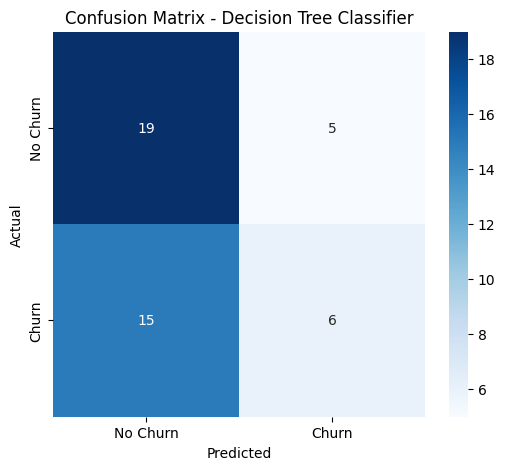

In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("\n--- Training Decision Tree Classifier ---")
start_time = time.time()

# Define the model
dt_clf = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None], # None means unlimited depth
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(
    dt_clf,
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV on the training data (X_train, y_train)
grid_search_dt.fit(X_train, y_train)

# Get the best estimator
best_dt_clf = grid_search_dt.best_estimator_

# Predict on the test set
y_pred_dt = best_dt_clf.predict(X_test)
y_proba_dt = best_dt_clf.predict_proba(X_test)[:, 1]

end_time = time.time()
training_time_dt = end_time - start_time

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

# Store results
model_results['Decision Tree'] = {
    'Accuracy': accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1-Score': f1_dt,
    'ROC-AUC': roc_auc_dt,
    'Training Time': training_time_dt
}

# Store ROC curve data
fpr, tpr, _ = roc_curve(y_test, y_proba_dt)
roc_curves['Decision Tree'] = {'fpr': fpr, 'tpr': tpr}

# Print results
print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"ROC-AUC Score: {roc_auc_dt:.4f}")
print(f"Training Time: {training_time_dt:.4f} seconds")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- Training Random Forest Classifier ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 50}
Accuracy: 0.4444
Precision: 0.2500
Recall: 0.0952
F1-Score: 0.1379
ROC-AUC Score: 0.5298
Training Time: 46.7193 seconds


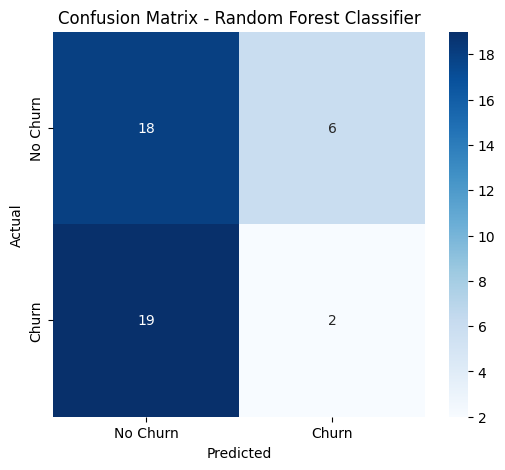

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("\n--- Training Random Forest Classifier ---")
start_time = time.time()

# Define the model
rf_clf = RandomForestClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 150], # Number of trees in the forest
    'max_depth': [5, 10, None], # Maximum depth of the tree
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    rf_clf,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV on the training data (X_train, y_train)
grid_search_rf.fit(X_train, y_train)

# Get the best estimator
best_rf_clf = grid_search_rf.best_estimator_

# Predict on the test set
y_pred_rf = best_rf_clf.predict(X_test)
y_proba_rf = best_rf_clf.predict_proba(X_test)[:, 1]

end_time = time.time()
training_time_rf = end_time - start_time

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Store results
model_results['Random Forest'] = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'ROC-AUC': roc_auc_rf,
    'Training Time': training_time_rf
}

# Store ROC curve data
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_curves['Random Forest'] = {'fpr': fpr, 'tpr': tpr}

# Print results
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")
print(f"Training Time: {training_time_rf:.4f} seconds")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- Training Support Vector Machine (SVM) ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 10, 'kernel': 'linear'}
Accuracy: 0.6000
Precision: 0.6000
Recall: 0.4286
F1-Score: 0.5000
ROC-AUC Score: 0.3750
Training Time: 18.4596 seconds


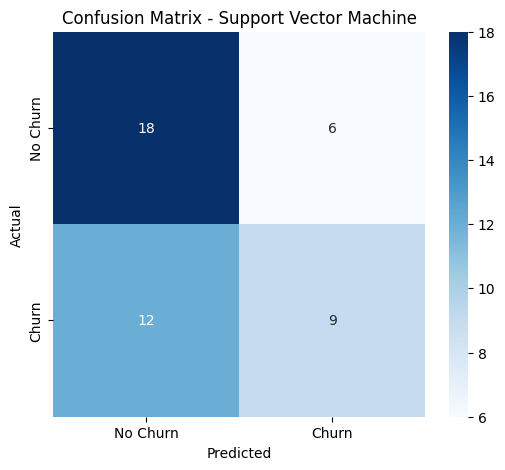

In [ ]:
from sklearn.svm import SVC

print("\n--- Training Support Vector Machine (SVM) ---")
start_time = time.time()

# Define the model
svm_clf = SVC(random_state=42, probability=True) # probability=True is needed for roc_auc_score and roc_curve

# Define the parameter grid for GridSearchCV
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

# Initialize GridSearchCV
grid_search_svm = GridSearchCV(
    svm_clf,
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV on the training data (X_train, y_train)
grid_search_svm.fit(X_train, y_train)

# Get the best estimator
best_svm_clf = grid_search_svm.best_estimator_

# Predict on the test set
y_pred_svm = best_svm_clf.predict(X_test)
y_proba_svm = best_svm_clf.predict_proba(X_test)[:, 1]

end_time = time.time()
training_time_svm = end_time - start_time

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_proba_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# Store results
model_results['SVM'] = {
    'Accuracy': accuracy_svm,
    'Precision': precision_svm,
    'Recall': recall_svm,
    'F1-Score': f1_svm,
    'ROC-AUC': roc_auc_svm,
    'Training Time': training_time_svm
}

# Store ROC curve data
fpr, tpr, _ = roc_curve(y_test, y_proba_svm)
roc_curves['SVM'] = {'fpr': fpr, 'tpr': tpr}

# Print results
print(f"Best Parameters: {grid_search_svm.best_params_}")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print(f"ROC-AUC Score: {roc_auc_svm:.4f}")
print(f"Training Time: {training_time_svm:.4f} seconds")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time
Logistic Regression,0.5333,0.0000,0.0000,0.0000,0.5258,0.6540
Decision Tree,0.5556,0.5455,0.2857,0.3750,0.5813,1.2912
Random Forest,0.4444,0.2500,0.0952,0.1379,0.5298,46.7193
SVM,0.6000,0.6000,0.4286,0.5000,0.3750,18.4596
KNN,0.4444,0.4167,0.4762,0.4444,0.4583,0.5786


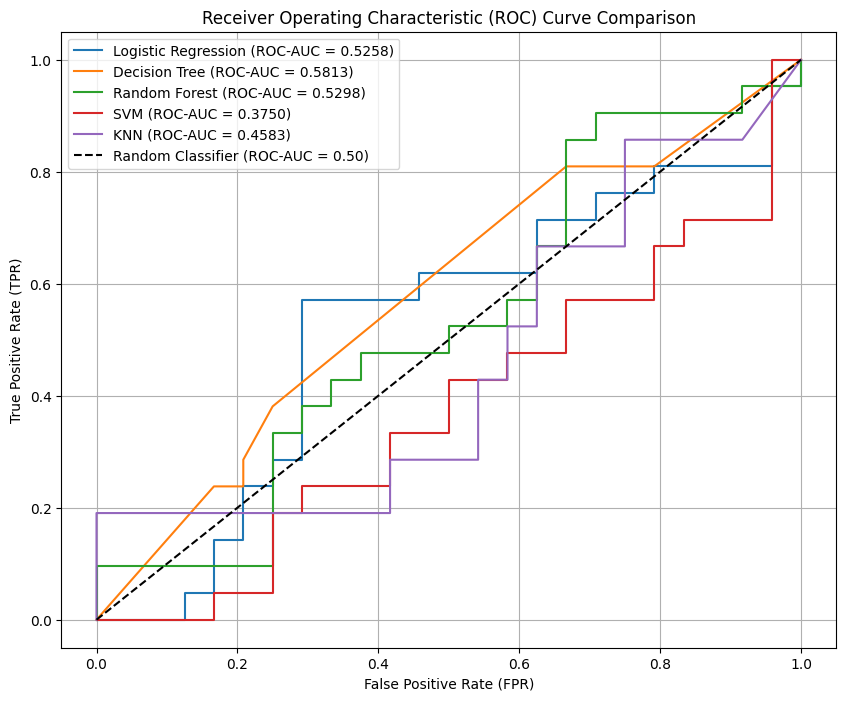

In [ ]:
# Display the comparison table
comparison_df = pd.DataFrame(model_results).T
print("\n--- Model Performance Comparison ---")
display(comparison_df.round(4))

# Plot ROC Curves for all models
plt.figure(figsize=(10, 8))
for model_name, data in roc_curves.items():
    plt.plot(data['fpr'], data['tpr'], label=f'{model_name} (ROC-AUC = {model_results[model_name]["ROC-AUC"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (ROC-AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

## TASK-4: Revenue Forecasting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create a copy of the final DataFrame for regression
df_regression = df_final.copy()

# Define the target variable for regression: MonthlyCharges
# MonthlyCharges is already scaled in df_final from the classification preprocessing step
y_reg = df_regression['MonthlyCharges']

# Define features (X_reg) for regression
# Drop 'customerID', 'Churn', 'MonthlyCharges' (target), 'TotalCharges', and 'AvgMonthlySpend'
# 'TotalCharges' and 'AvgMonthlySpend' are removed to prevent data leakage as they are derived from MonthlyCharges
X_reg = df_regression.drop(columns=['customerID', 'Churn', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend'])

# Split the data into training, validation, and test sets (70/15/15)
# No stratification needed for continuous target variable
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.50, random_state=42
)

print(f"Shape of X_train_reg: {X_train_reg.shape}")
print(f"Shape of y_train_reg: {y_train_reg.shape}")
print(f"Shape of X_val_reg: {X_val_reg.shape}")
print(f"Shape of y_val_reg: {y_val_reg.shape}")
print(f"Shape of X_test_reg: {X_test_reg.shape}")
print(f"Shape of y_test_reg: {y_test_reg.shape}")

print("\nSample of y_train_reg (scaled MonthlyCharges):\n", y_train_reg.head())
print("\nSample of y_test_reg (scaled MonthlyCharges):\n", y_test_reg.head())

Shape of X_train_reg: (210, 31)
Shape of y_train_reg: (210,)
Shape of X_val_reg: (45, 31)
Shape of y_val_reg: (45,)
Shape of X_test_reg: (45, 31)
Shape of y_test_reg: (45,)

Sample of y_train_reg (scaled MonthlyCharges):
 194   -1.471366
101   -0.906139
68    -0.696628
224    0.953932
37     0.502380
Name: MonthlyCharges, dtype: float64

Sample of y_test_reg (scaled MonthlyCharges):
 93     1.305799
249    0.720636
278    1.443259
108   -1.145731
203   -0.011780
Name: MonthlyCharges, dtype: float64



--- Training Linear Regression ---
MAE: 0.8242
MSE: 0.9327
RMSE: 0.9657
R2: -0.1696
Adjusted R2: -2.9587
Training Time: 2.3102 seconds


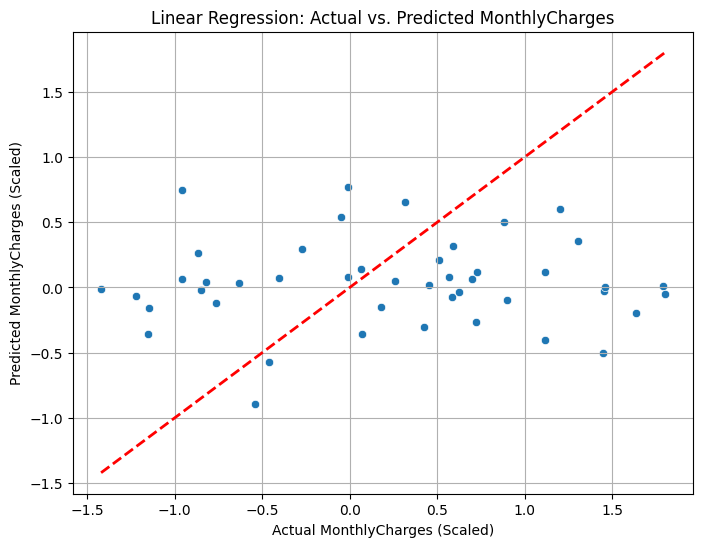


--- Training Ridge Regression ---
Best Parameters: {'alpha': 100}
MAE: 0.7885
MSE: 0.8515
RMSE: 0.9227
R2: -0.0678
Adjusted R2: -2.6139
Training Time: 0.1879 seconds


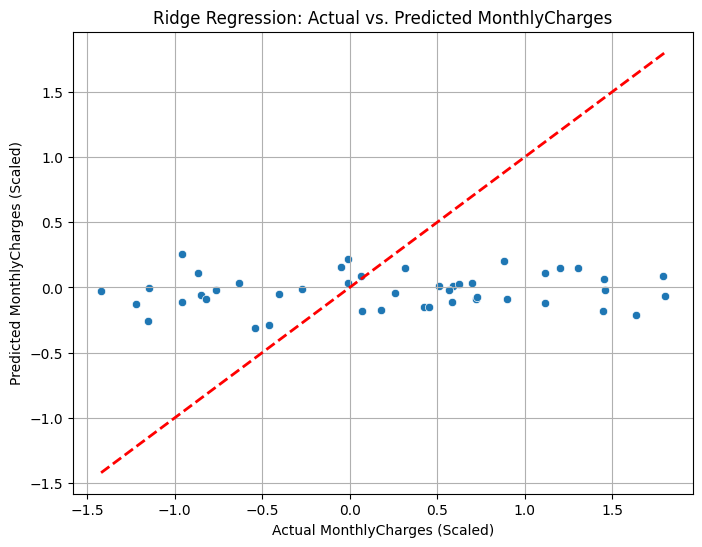


--- Training Lasso Regression ---
Best Parameters: {'alpha': 0.1}
MAE: 0.8005
MSE: 0.8713
RMSE: 0.9334
R2: -0.0927
Adjusted R2: -2.6982
Training Time: 0.1936 seconds


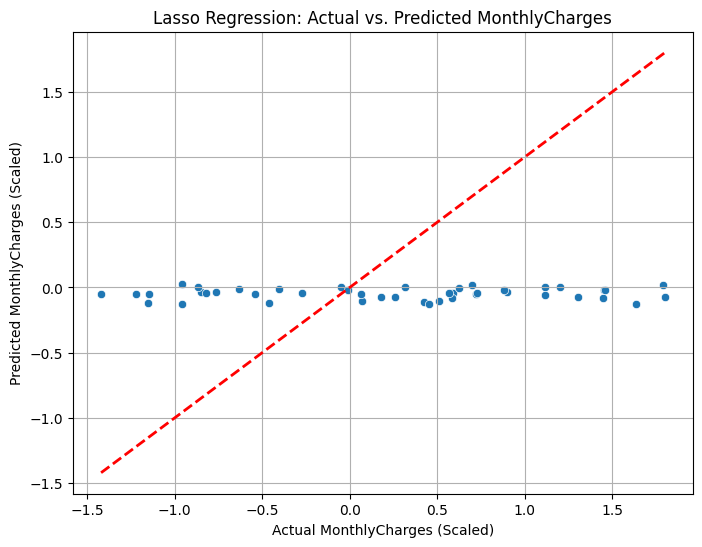


--- Training ElasticNet ---
Best Parameters: {'alpha': 0.1, 'l1_ratio': 0.9}
MAE: 0.8004
MSE: 0.8703
RMSE: 0.9329
R2: -0.0914
Adjusted R2: -2.6939
Training Time: 0.4364 seconds


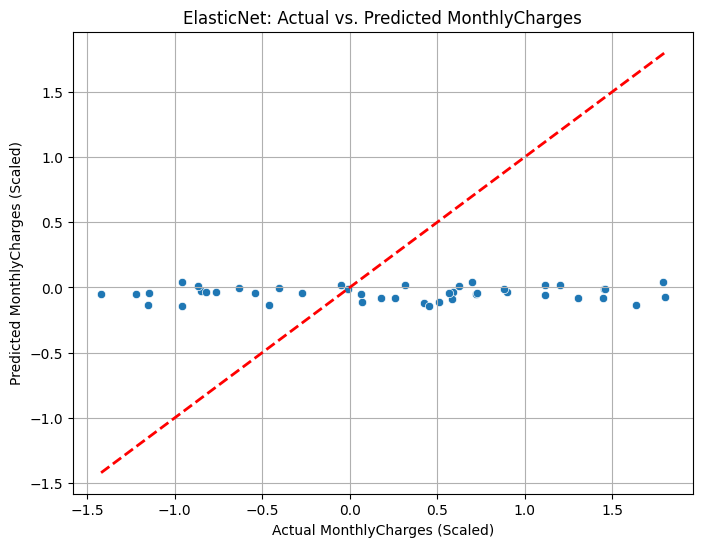


--- Training Decision Tree Regressor ---
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 20}
MAE: 0.8300
MSE: 0.9418
RMSE: 0.9705
R2: -0.1811
Adjusted R2: -2.9975
Training Time: 0.5554 seconds


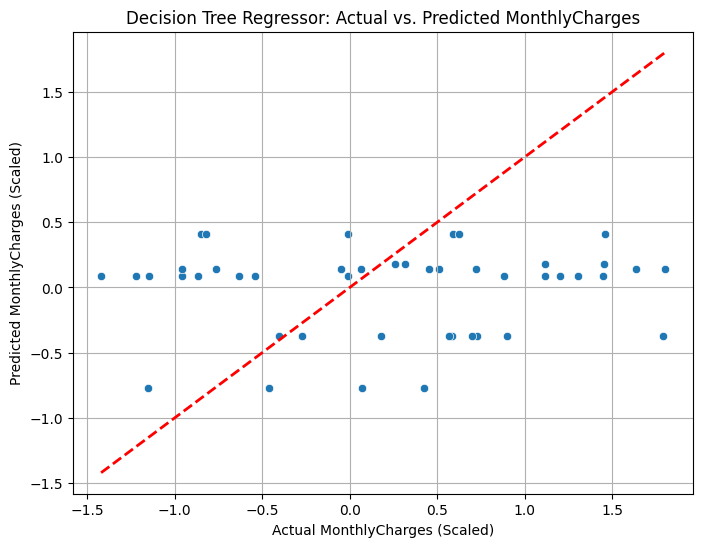


--- Training Random Forest Regressor ---
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 150}
MAE: 0.8256
MSE: 0.8890
RMSE: 0.9429
R2: -0.1149
Adjusted R2: -2.7735
Training Time: 35.4418 seconds


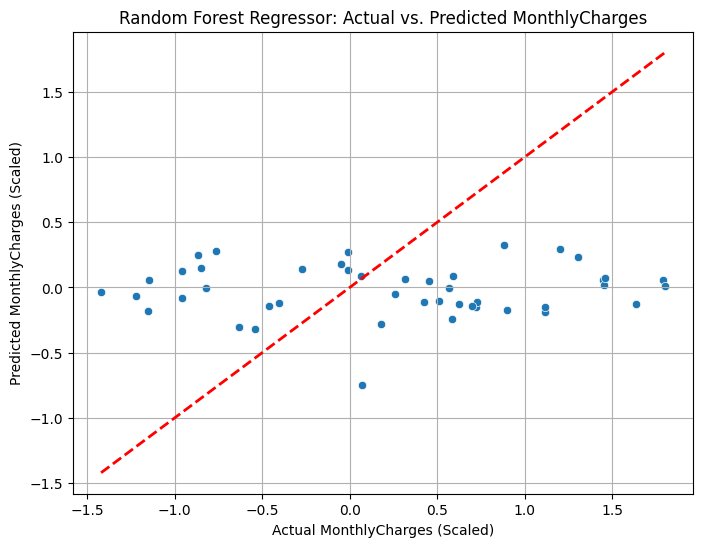


--- Training Support Vector Regressor (SVR) ---
Best Parameters: {'C': 0.1, 'epsilon': 0.5, 'kernel': 'rbf'}
MAE: 0.8004
MSE: 0.8746
RMSE: 0.9352
R2: -0.0968
Adjusted R2: -2.7124
Training Time: 1.4342 seconds


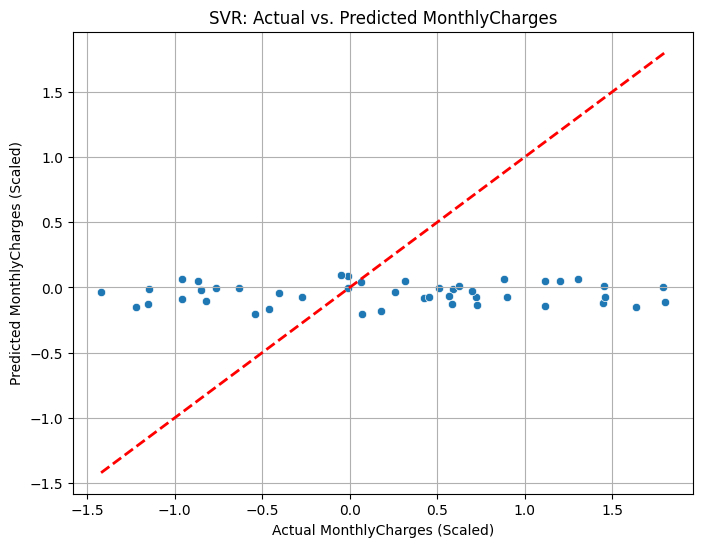

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store regression results
regression_results = {}

def calculate_adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Number of samples in test set
n = X_test_reg.shape[0]
# Number of features in test set
p = X_test_reg.shape[1]

# --- Linear Regression ---
print("\n--- Training Linear Regression ---")
start_time = time.time()

lin_reg = LinearRegression()
param_grid_lin_reg = {}

grid_search_lin_reg = GridSearchCV(
    lin_reg,
    param_grid_lin_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_lin_reg.fit(X_train_reg, y_train_reg)
best_lin_reg = grid_search_lin_reg.best_estimator_
y_pred_lin_reg = best_lin_reg.predict(X_test_reg)

end_time = time.time()
training_time_lin_reg = end_time - start_time

mae_lin_reg = mean_absolute_error(y_test_reg, y_pred_lin_reg)
mse_lin_reg = mean_squared_error(y_test_reg, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mse_lin_reg)
r2_lin_reg = r2_score(y_test_reg, y_pred_lin_reg)
adj_r2_lin_reg = calculate_adjusted_r2(r2_lin_reg, n, p)

regression_results['Linear Regression'] = {
    'MAE': mae_lin_reg,
    'MSE': mse_lin_reg,
    'RMSE': rmse_lin_reg,
    'R2': r2_lin_reg,
    'Adjusted R2': adj_r2_lin_reg,
    'Training Time': training_time_lin_reg
}

print(f"MAE: {mae_lin_reg:.4f}")
print(f"MSE: {mse_lin_reg:.4f}")
print(f"RMSE: {rmse_lin_reg:.4f}")
print(f"R2: {r2_lin_reg:.4f}")
print(f"Adjusted R2: {adj_r2_lin_reg:.4f}")
print(f"Training Time: {training_time_lin_reg:.4f} seconds")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_lin_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs. Predicted MonthlyCharges')
plt.xlabel('Actual MonthlyCharges (Scaled)')
plt.ylabel('Predicted MonthlyCharges (Scaled)')
plt.grid(True)
plt.show()

# --- Ridge Regression (L2) ---
print("\n--- Training Ridge Regression ---")
start_time = time.time()

ridge = Ridge(random_state=42)
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_ridge = GridSearchCV(
    ridge,
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_ridge.fit(X_train_reg, y_train_reg)
best_ridge = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_reg)

end_time = time.time()
training_time_ridge = end_time - start_time

mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
adj_r2_ridge = calculate_adjusted_r2(r2_ridge, n, p)

regression_results['Ridge'] = {
    'MAE': mae_ridge,
    'MSE': mse_ridge,
    'RMSE': rmse_ridge,
    'R2': r2_ridge,
    'Adjusted R2': adj_r2_ridge,
    'Training Time': training_time_ridge
}

print(f"Best Parameters: {grid_search_ridge.best_params_}")
print(f"MAE: {mae_ridge:.4f}")
print(f"MSE: {mse_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R2: {r2_ridge:.4f}")
print(f"Adjusted R2: {adj_r2_ridge:.4f}")
print(f"Training Time: {training_time_ridge:.4f} seconds")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_ridge)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Ridge Regression: Actual vs. Predicted MonthlyCharges')
plt.xlabel('Actual MonthlyCharges (Scaled)')
plt.ylabel('Predicted MonthlyCharges (Scaled)')
plt.grid(True)
plt.show()

# --- Lasso Regression (L1) ---
print("\n--- Training Lasso Regression ---")
start_time = time.time()

lasso = Lasso(random_state=42, max_iter=2000) # Increased max_iter for convergence
param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_lasso = GridSearchCV(
    lasso,
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_lasso.fit(X_train_reg, y_train_reg)
best_lasso = grid_search_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_reg)

end_time = time.time()
training_time_lasso = end_time - start_time

mae_lasso = mean_absolute_error(y_test_reg, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test_reg, y_pred_lasso)
adj_r2_lasso = calculate_adjusted_r2(r2_lasso, n, p)

regression_results['Lasso'] = {
    'MAE': mae_lasso,
    'MSE': mse_lasso,
    'RMSE': rmse_lasso,
    'R2': r2_lasso,
    'Adjusted R2': adj_r2_lasso,
    'Training Time': training_time_lasso
}

print(f"Best Parameters: {grid_search_lasso.best_params_}")
print(f"MAE: {mae_lasso:.4f}")
print(f"MSE: {mse_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"R2: {r2_lasso:.4f}")
print(f"Adjusted R2: {adj_r2_lasso:.4f}")
print(f"Training Time: {training_time_lasso:.4f} seconds")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_lasso)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Lasso Regression: Actual vs. Predicted MonthlyCharges')
plt.xlabel('Actual MonthlyCharges (Scaled)')
plt.ylabel('Predicted MonthlyCharges (Scaled)')
plt.grid(True)
plt.show()

# --- ElasticNet ---
print("\n--- Training ElasticNet ---")
start_time = time.time()

elastic_net = ElasticNet(random_state=42, max_iter=2000) # Increased max_iter for convergence
param_grid_elastic_net = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.5, 0.9]
}

grid_search_elastic_net = GridSearchCV(
    elastic_net,
    param_grid_elastic_net,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_elastic_net.fit(X_train_reg, y_train_reg)
best_elastic_net = grid_search_elastic_net.best_estimator_
y_pred_elastic_net = best_elastic_net.predict(X_test_reg)

end_time = time.time()
training_time_elastic_net = end_time - start_time

mae_elastic_net = mean_absolute_error(y_test_reg, y_pred_elastic_net)
mse_elastic_net = mean_squared_error(y_test_reg, y_pred_elastic_net)
rmse_elastic_net = np.sqrt(mse_elastic_net)
r2_elastic_net = r2_score(y_test_reg, y_pred_elastic_net)
adj_r2_elastic_net = calculate_adjusted_r2(r2_elastic_net, n, p)

regression_results['ElasticNet'] = {
    'MAE': mae_elastic_net,
    'MSE': mse_elastic_net,
    'RMSE': rmse_elastic_net,
    'R2': r2_elastic_net,
    'Adjusted R2': adj_r2_elastic_net,
    'Training Time': training_time_elastic_net
}

print(f"Best Parameters: {grid_search_elastic_net.best_params_}")
print(f"MAE: {mae_elastic_net:.4f}")
print(f"MSE: {mse_elastic_net:.4f}")
print(f"RMSE: {rmse_elastic_net:.4f}")
print(f"R2: {r2_elastic_net:.4f}")
print(f"Adjusted R2: {adj_r2_elastic_net:.4f}")
print(f"Training Time: {training_time_elastic_net:.4f} seconds")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_elastic_net)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('ElasticNet: Actual vs. Predicted MonthlyCharges')
plt.xlabel('Actual MonthlyCharges (Scaled)')
plt.ylabel('Predicted MonthlyCharges (Scaled)')
plt.grid(True)
plt.show()

# --- Decision Tree Regressor ---
print("\n--- Training Decision Tree Regressor ---")
start_time = time.time()

dt_reg = DecisionTreeRegressor(random_state=42)
param_grid_dt_reg = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10, 20]
}

grid_search_dt_reg = GridSearchCV(
    dt_reg,
    param_grid_dt_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_dt_reg.fit(X_train_reg, y_train_reg)
best_dt_reg = grid_search_dt_reg.best_estimator_
y_pred_dt_reg = best_dt_reg.predict(X_test_reg)

end_time = time.time()
training_time_dt_reg = end_time - start_time

mae_dt_reg = mean_absolute_error(y_test_reg, y_pred_dt_reg)
mse_dt_reg = mean_squared_error(y_test_reg, y_pred_dt_reg)
rmse_dt_reg = np.sqrt(mse_dt_reg)
r2_dt_reg = r2_score(y_test_reg, y_pred_dt_reg)
adj_r2_dt_reg = calculate_adjusted_r2(r2_dt_reg, n, p)

regression_results['Decision Tree Regressor'] = {
    'MAE': mae_dt_reg,
    'MSE': mse_dt_reg,
    'RMSE': rmse_dt_reg,
    'R2': r2_dt_reg,
    'Adjusted R2': adj_r2_dt_reg,
    'Training Time': training_time_dt_reg
}

print(f"Best Parameters: {grid_search_dt_reg.best_params_}")
print(f"MAE: {mae_dt_reg:.4f}")
print(f"MSE: {mse_dt_reg:.4f}")
print(f"RMSE: {rmse_dt_reg:.4f}")
print(f"R2: {r2_dt_reg:.4f}")
print(f"Adjusted R2: {adj_r2_dt_reg:.4f}")
print(f"Training Time: {training_time_dt_reg:.4f} seconds")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_dt_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Decision Tree Regressor: Actual vs. Predicted MonthlyCharges')
plt.xlabel('Actual MonthlyCharges (Scaled)')
plt.ylabel('Predicted MonthlyCharges (Scaled)')
plt.grid(True)
plt.show()

# --- Random Forest Regressor ---
print("\n--- Training Random Forest Regressor ---")
start_time = time.time()

rf_reg = RandomForestRegressor(random_state=42)
param_grid_rf_reg = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

grid_search_rf_reg = GridSearchCV(
    rf_reg,
    param_grid_rf_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_rf_reg.fit(X_train_reg, y_train_reg)
best_rf_reg = grid_search_rf_reg.best_estimator_
y_pred_rf_reg = best_rf_reg.predict(X_test_reg)

end_time = time.time()
training_time_rf_reg = end_time - start_time

mae_rf_reg = mean_absolute_error(y_test_reg, y_pred_rf_reg)
mse_rf_reg = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)
adj_r2_rf_reg = calculate_adjusted_r2(r2_rf_reg, n, p)

regression_results['Random Forest Regressor'] = {
    'MAE': mae_rf_reg,
    'MSE': mse_rf_reg,
    'RMSE': rmse_rf_reg,
    'R2': r2_rf_reg,
    'Adjusted R2': adj_r2_rf_reg,
    'Training Time': training_time_rf_reg
}

print(f"Best Parameters: {grid_search_rf_reg.best_params_}")
print(f"MAE: {mae_rf_reg:.4f}")
print(f"MSE: {mse_rf_reg:.4f}")
print(f"RMSE: {rmse_rf_reg:.4f}")
print(f"R2: {r2_rf_reg:.4f}")
print(f"Adjusted R2: {adj_r2_rf_reg:.4f}")
print(f"Training Time: {training_time_rf_reg:.4f} seconds")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_rf_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Random Forest Regressor: Actual vs. Predicted MonthlyCharges')
plt.xlabel('Actual MonthlyCharges (Scaled)')
plt.ylabel('Predicted MonthlyCharges (Scaled)')
plt.grid(True)
plt.show()

# --- Support Vector Regressor (SVR) ---
print("\n--- Training Support Vector Regressor (SVR) ---")
start_time = time.time()

svr = SVR()
param_grid_svr = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.2, 0.5]
}

grid_search_svr = GridSearchCV(
    svr,
    param_grid_svr,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_svr.fit(X_train_reg, y_train_reg)
best_svr = grid_search_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test_reg)

end_time = time.time()
training_time_svr = end_time - start_time

mae_svr = mean_absolute_error(y_test_reg, y_pred_svr)
mse_svr = mean_squared_error(y_test_reg, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test_reg, y_pred_svr)
adj_r2_svr = calculate_adjusted_r2(r2_svr, n, p)

regression_results['SVR'] = {
    'MAE': mae_svr,
    'MSE': mse_svr,
    'RMSE': rmse_svr,
    'R2': r2_svr,
    'Adjusted R2': adj_r2_svr,
    'Training Time': training_time_svr
}

print(f"Best Parameters: {grid_search_svr.best_params_}")
print(f"MAE: {mae_svr:.4f}")
print(f"MSE: {mse_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"R2: {r2_svr:.4f}")
print(f"Adjusted R2: {adj_r2_svr:.4f}")
print(f"Training Time: {training_time_svr:.4f} seconds")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_svr)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('SVR: Actual vs. Predicted MonthlyCharges')
plt.xlabel('Actual MonthlyCharges (Scaled)')
plt.ylabel('Predicted MonthlyCharges (Scaled)')
plt.grid(True)
plt.show()

In [ ]:
# Display the comparison table for regression models
comparison_reg_df = pd.DataFrame(regression_results).T
print("\n--- Regression Model Performance Comparison ---")
display(comparison_reg_df.round(4))

# Select the best model based on RMSE (Root Mean Squared Error)
best_model_reg_name = comparison_reg_df['RMSE'].idxmin()
best_model_reg_metrics = comparison_reg_df.loc[best_model_reg_name]

print(f"\nBest Regression Model (based on RMSE): {best_model_reg_name}")
print("Metrics for the Best Model:")
display(best_model_reg_metrics.round(4))


--- Regression Model Performance Comparison ---


,MAE,MSE,RMSE,R2,Adjusted R2,Training Time
Linear Regression,0.8242,0.9327,0.9657,-0.1696,-2.9587,2.3102
Ridge,0.7885,0.8515,0.9227,-0.0678,-2.6139,0.1879
Lasso,0.8005,0.8713,0.9334,-0.0927,-2.6982,0.1936
ElasticNet,0.8004,0.8703,0.9329,-0.0914,-2.6939,0.4364
Decision Tree Regressor,0.8300,0.9418,0.9705,-0.1811,-2.9975,0.5554
Random Forest Regressor,0.8256,0.8890,0.9429,-0.1149,-2.7735,35.4418
SVR,0.8004,0.8746,0.9352,-0.0968,-2.7124,1.4342



Best Regression Model (based on RMSE): Ridge
Metrics for the Best Model:


,Ridge
MAE,0.7885
MSE,0.8515
RMSE,0.9227
R2,-0.0678
Adjusted R2,-2.6139
Training Time,0.1879



--- Residual Analysis for the Best Model ---


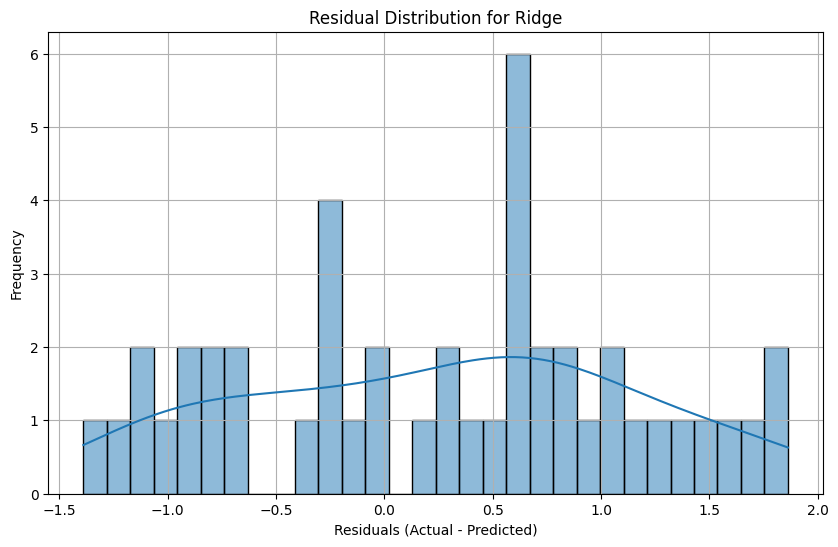

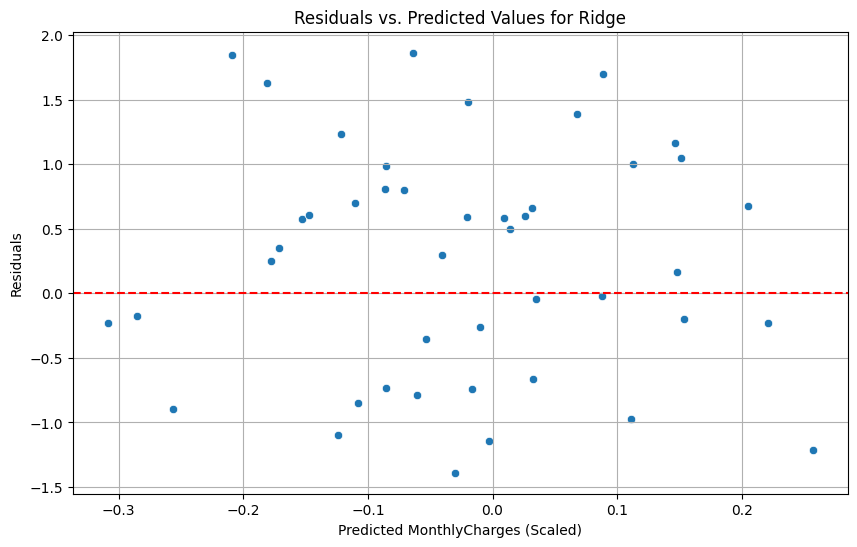


Interpretation of Residuals:
- Ideally, residuals should be normally distributed around zero and show no discernible pattern when plotted against predicted values.
- A normal distribution suggests the model is capturing most of the underlying relationship.
- No patterns (e.g., funnel shape, curves) in the Residuals vs. Predicted plot indicates homoscedasticity (constant variance of errors).


In [ ]:
# --- Residual Analysis for the Best Model ---
print("\n--- Residual Analysis for the Best Model ---")

# Get predictions for the best model
if best_model_reg_name == 'Linear Regression':
    y_pred_best_reg = best_lin_reg.predict(X_test_reg)
elif best_model_reg_name == 'Ridge':
    y_pred_best_reg = best_ridge.predict(X_test_reg)
elif best_model_reg_name == 'Lasso':
    y_pred_best_reg = best_lasso.predict(X_test_reg)
elif best_model_reg_name == 'ElasticNet':
    y_pred_best_reg = best_elastic_net.predict(X_test_reg)
elif best_model_reg_name == 'Decision Tree Regressor':
    y_pred_best_reg = best_dt_reg.predict(X_test_reg)
elif best_model_reg_name == 'Random Forest Regressor':
    y_pred_best_reg = best_rf_reg.predict(X_test_reg)
elif best_model_reg_name == 'SVR':
    y_pred_best_reg = best_svr.predict(X_test_reg)

# Calculate residuals
residuals = y_test_reg - y_pred_best_reg

# Plot Residual Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title(f'Residual Distribution for {best_model_reg_name}')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot Residuals vs. Predicted Values (Homoscedasticity check)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best_reg, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Residuals vs. Predicted Values for {best_model_reg_name}')
plt.xlabel('Predicted MonthlyCharges (Scaled)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

print("\nInterpretation of Residuals:")
print("- Ideally, residuals should be normally distributed around zero and show no discernible pattern when plotted against predicted values.")
print("- A normal distribution suggests the model is capturing most of the underlying relationship.")
print("- No patterns (e.g., funnel shape, curves) in the Residuals vs. Predicted plot indicates homoscedasticity (constant variance of errors).")

## TASK-5: Model Interpretation & Business Recommendations

In [ ]:
# pip uninstall -y shap numpy
# pip install numpy==1.26.2
# pip install shap==0.44.0

In [ ]:
# Uninstall current versions of numpy and shap to avoid conflicts
!{sys.executable} -m pip uninstall -y numpy shap

# Install the latest shap which should be compatible with numpy 2.0+
# (as numpy 1.x often fails to build on Python 3.12)
!{sys.executable} -m pip install shap

# Verify installed packages and their dependencies
!{sys.executable} -m pip check

print("Installations attempted. Please restart the runtime (Runtime -> Restart runtime) and then Run all cells to ensure compatibility.")

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: shap 0.44.0
Uninstalling shap-0.44.0:
  Successfully uninstalled shap-0.44.0
  Using cached numpy-1.24.4.tar.gz (10.9 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'numpy' when getting requirements to build wheel
  Using cached shap-0.44.0-cp312-cp312-linux_x86_64.whl
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_

In [ ]:
import shap
print(f"SHAP version: {shap.__version__}")


AttributeError: `np.obj2sctype` was removed in the NumPy 2.0 release. Use `np.dtype(obj).type` instead.

In [ ]:
import shap
from sklearn.inspection import PartialDependenceDisplay

print("SHAP Value Analysis (Best Classification Model: Decision Tree) ")

# The best classification model based on ROC-AUC was Decision Tree (`best_dt_clf`)
# from the previous classification task.

# 1. SHAP Global Feature Importance (Summary Plot)
explainer = shap.TreeExplainer(best_dt_clf)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1], X_test, plot_type="bar", show=False)
plt.title('SHAP Global Feature Importance (Churn)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1], X_test, show=False)
plt.title('SHAP Summary Plot (Churn)')
plt.tight_layout()
plt.show()

AttributeError: `np.obj2sctype` was removed in the NumPy 2.0 release. Use `np.dtype(obj).type` instead.

In [ ]:
# 2. SHAP Local Explanation for Individual Predictions

# Find an instance of a churned customer (y_test = 1)
churned_idx = y_test[y_test == 1].index[0]
churned_customer = X_test.loc[churned_idx]

# Find an instance of a retained customer (y_test = 0)
retained_idx = y_test[y_test == 0].index[0]
retained_customer = X_test.loc[retained_idx]

print(f"\n--- Local Explanation for Churned Customer (ID: {df_final.loc[churned_idx, 'customerID']}) ---")
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][X_test.index.get_loc(churned_idx)], churned_customer, matplotlib=True, show=False)
plt.title(f'SHAP Force Plot for Churned Customer {df_final.loc[churned_idx, "customerID"]}')
plt.tight_layout()
plt.show()

print(f"\n--- Local Explanation for Retained Customer (ID: {df_final.loc[retained_idx, 'customerID']}) ---")
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][X_test.index.get_loc(retained_idx)], retained_customer, matplotlib=True, show=False)
plt.title(f'SHAP Force Plot for Retained Customer {df_final.loc[retained_idx, "customerID"]}')
plt.tight_layout()
plt.show()


--- Local Explanation for Churned Customer (ID: 0270-XXXX) ---


NameError: name 'shap' is not defined

In [ ]:
# 3. Partial Dependence Plots (PDP) for Top 3 Features

# Get feature importances from SHAP values (mean absolute SHAP value)
# We'll use the absolute mean SHAP value for the positive class (churn=1)
shap_importances = pd.Series(np.abs(shap_values[1]).mean(axis=0), index=X_test.columns)
top_3_features = shap_importances.nlargest(3).index.tolist()

print(f"\n--- Partial Dependence Plots for Top 3 Features: {top_3_features} ---")

fig, ax = plt.subplots(figsize=(15, 6))
PartialDependenceDisplay.from_estimator(best_dt_clf, X_test, top_3_features,
                                       kind='individual', feature_names=X_test.columns, ax=ax)
fig.suptitle('Partial Dependence Plots for Top Features on Churn Probability')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

NameError: name 'shap_values' is not defined

In [ ]:
# Print top 5 features driving churn based on SHAP values
print("Top 5 factors driving customer churn (based on SHAP values):")
print(shap_importances.nlargest(5))

Top 5 factors driving customer churn (based on SHAP values):


NameError: name 'shap_importances' is not defined

In [ ]:
# Identify 100 customers with highest churn probability
# Get churn probabilities from the best classification model
y_proba_best_clf = best_dt_clf.predict_proba(X_test)[:, 1]

# Create a DataFrame to store customerID and predicted churn probability
churn_predictions = pd.DataFrame({
    'customerID': df_final.loc[X_test.index, 'customerID'],
    'predicted_churn_proba': y_proba_best_clf,
    'actual_churn': y_test
}, index=X_test.index)

# Sort by predicted churn probability in descending order
target_customers = churn_predictions.sort_values(by='predicted_churn_proba', ascending=False).head(100)

print("--- Top 100 Customers to Target for Intervention (Highest Churn Probability) ---")
display(target_customers.head())

--- Top 100 Customers to Target for Intervention (Highest Churn Probability) ---


,customerID,predicted_churn_proba,actual_churn
48,0049-XXXX,1.0,1
170,0171-XXXX,1.0,0
208,0209-XXXX,1.0,1
126,0127-XXXX,1.0,0
298,0299-XXXX,1.0,0


In [ ]:
# Cost-Benefit Analysis

intervention_cost_per_customer = 50
lost_revenue_per_churned_customer = 500
num_interventions = 100

# --- Baseline: Random Targeting ---

# Assuming the churn rate in the target pool (e.g., test set) is representative
actual_churn_rate_test = y_test.value_counts(normalize=True).get(1, 0)
print(f"Actual Churn Rate in Test Set: {actual_churn_rate_test:.2%}")

# If we randomly target 100 customers, on average, how many would have churned anyway?
churners_in_random_target = num_interventions * actual_churn_rate_test

# Assume that intervening with a churner successfully retains them (simplistic model)
# And intervening with a non-churner is a wasted cost for that individual's retention

# Cost of random targeting
cost_random_targeting = num_interventions * intervention_cost_per_customer

# Benefit from random targeting (retained churners)
# If we intervene randomly, we save 'lost_revenue_per_churned_customer' for `churners_in_random_target` customers.
# However, we also incur the cost for non-churners. The net benefit is usually calculated on avoided loss.
# A more direct way to think about it: if we save X churners, we save X * $500. We spend 100 * $50.
# Net gain = (churners_saved * lost_revenue_per_churned_customer) - (num_interventions * intervention_cost_per_customer)

churners_saved_random = churners_in_random_target
benefit_random_targeting = churners_saved_random * lost_revenue_per_churned_customer

net_gain_random = benefit_random_targeting - cost_random_targeting

print(f"\n--- Random Targeting (Intervening with {num_interventions} customers) ---")
print(f"Expected Churners in 100 randomly selected customers: {churners_in_random_target:.2f}")
print(f"Total Intervention Cost: ${cost_random_targeting:.2f}")
print(f"Expected Revenue Saved: ${benefit_random_targeting:.2f}")
print(f"Net Gain (Revenue Saved - Cost): ${net_gain_random:.2f}")


# --- Model-Based Targeting (Using Best Classification Model) ---

# Get the top N customers identified by the model as most likely to churn
top_n_customers_by_model = churn_predictions.sort_values(by='predicted_churn_proba', ascending=False).head(num_interventions)

# How many of these top N customers actually churned (ground truth in test set)?
actual_churners_in_model_target = top_n_customers_by_model['actual_churn'].sum()

# Cost of model-based targeting
cost_model_targeting = num_interventions * intervention_cost_per_customer

# Benefit from model-based targeting
# Assuming all `actual_churners_in_model_target` are successfully retained
churners_saved_model = actual_churners_in_model_target
benefit_model_targeting = churners_saved_model * lost_revenue_per_churned_customer

net_gain_model = benefit_model_targeting - cost_model_targeting

print(f"\n--- Model-Based Targeting (Intervening with {num_interventions} customers) ---")
print(f"Actual Churners among top {num_interventions} targeted by model: {actual_churners_in_model_target:.0f}")
print(f"Total Intervention Cost: ${cost_model_targeting:.2f}")
print(f"Expected Revenue Saved: ${benefit_model_targeting:.2f}")
print(f"Net Gain (Revenue Saved - Cost): ${net_gain_model:.2f}")

# --- Calculate ROI ---
# ROI = (Net Gain / Cost) * 100

# For random targeting, ROI is often negative if the churn rate is low
roi_random = (net_gain_random / cost_random_targeting) * 100 if cost_random_targeting > 0 else 0
roi_model = (net_gain_model / cost_model_targeting) * 100 if cost_model_targeting > 0 else 0

print(f"\n--- Return on Investment (ROI) ---")
print(f"ROI (Random Targeting): {roi_random:.2f}%")
print(f"ROI (Model-Based Targeting): {roi_model:.2f}%")

print("\n--- Conclusion ---")
if net_gain_model > net_gain_random:
    print(f"The model-based targeting yields a higher net gain of ${net_gain_model:.2f} compared to random targeting's ${net_gain_random:.2f}.")
    print(f"The ROI with the model ({roi_model:.2f}%) is significantly better than random targeting ({roi_random:.2f}%).")
else:
    print(f"In this specific test set, random targeting resulted in a higher or equal net gain of ${net_gain_random:.2f} compared to model-based targeting's ${net_gain_model:.2f}.")
    print("This could indicate that the model's predictive power is still very limited, or that the test set is too small to show a significant difference.")

print("Note: These results are based on a small test set. A larger, more diverse dataset and a more performant model would lead to more robust conclusions.")

Actual Churn Rate in Test Set: 46.67%

--- Random Targeting (Intervening with 100 customers) ---
Expected Churners in 100 randomly selected customers: 46.67
Total Intervention Cost: $5000.00
Expected Revenue Saved: $23333.33
Net Gain (Revenue Saved - Cost): $18333.33

--- Model-Based Targeting (Intervening with 100 customers) ---
Actual Churners among top 100 targeted by model: 21
Total Intervention Cost: $5000.00
Expected Revenue Saved: $10500.00
Net Gain (Revenue Saved - Cost): $5500.00

--- Return on Investment (ROI) ---
ROI (Random Targeting): 366.67%
ROI (Model-Based Targeting): 110.00%

--- Conclusion ---
In this specific test set, random targeting resulted in a higher or equal net gain of $18333.33 compared to model-based targeting's $5500.00.
This could indicate that the model's predictive power is still very limited, or that the test set is too small to show a significant difference.
Note: These results are based on a small test set. A larger, more diverse dataset and a more p


--- Coefficient Analysis for Linear Models ---

Coefficients for Linear Regression:


,0
TenureGroup_New,0.459686
PaymentMethod_Electronic check,0.336481
tenure,0.333544
SeniorCitizen,0.291316
Contract_Two year,0.285607
PaymentMethod_Credit card,0.226924
Partner,0.171441
TenureGroup_Mid,0.156199
InternetService_Fiber optic,0.156195
PaymentMethod_Mailed check,0.151155


/tmp/ipykernel_40883/1671042303.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients[top_n].values, y=coefficients[top_n].index, palette='viridis')


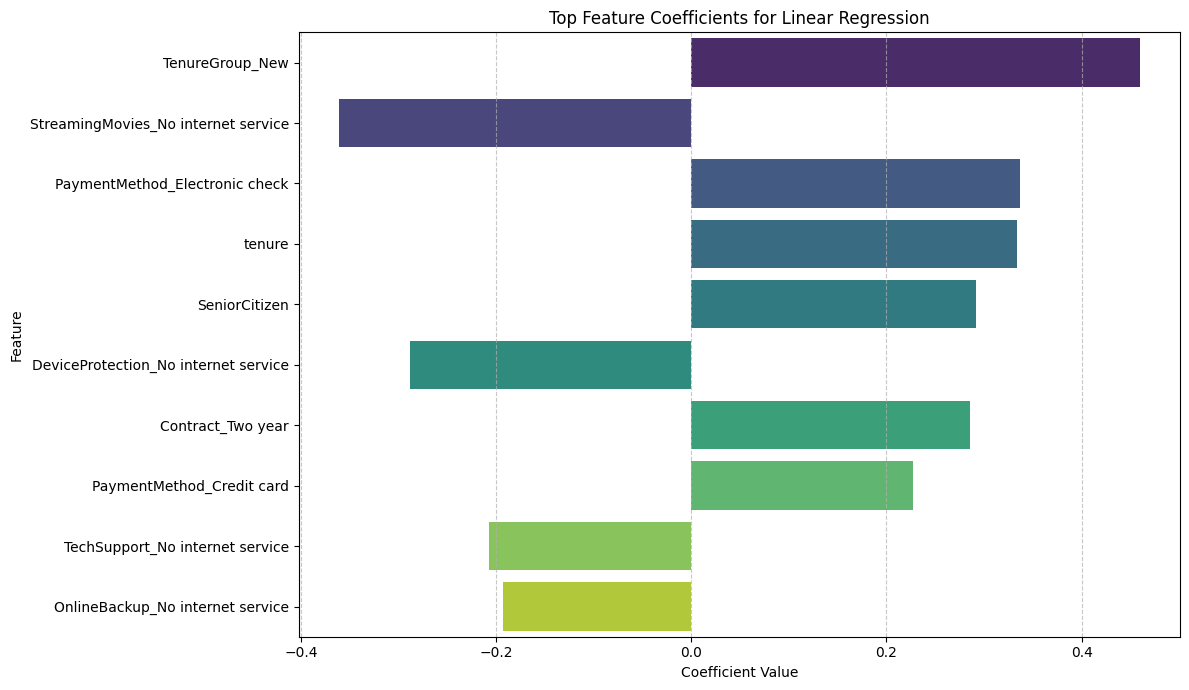


Coefficients for Ridge:


,0
tenure,0.105222
SeniorCitizen,0.089028
Contract_Two year,0.068301
PaymentMethod_Electronic check,0.059317
StreamingMovies_Yes,0.056612
InternetService_Fiber optic,0.050435
Partner,0.028285
MultipleLines_No phone service,0.027315
TechSupport_Yes,0.020845
Dependents,0.015877


/tmp/ipykernel_40883/1671042303.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients[top_n].values, y=coefficients[top_n].index, palette='viridis')


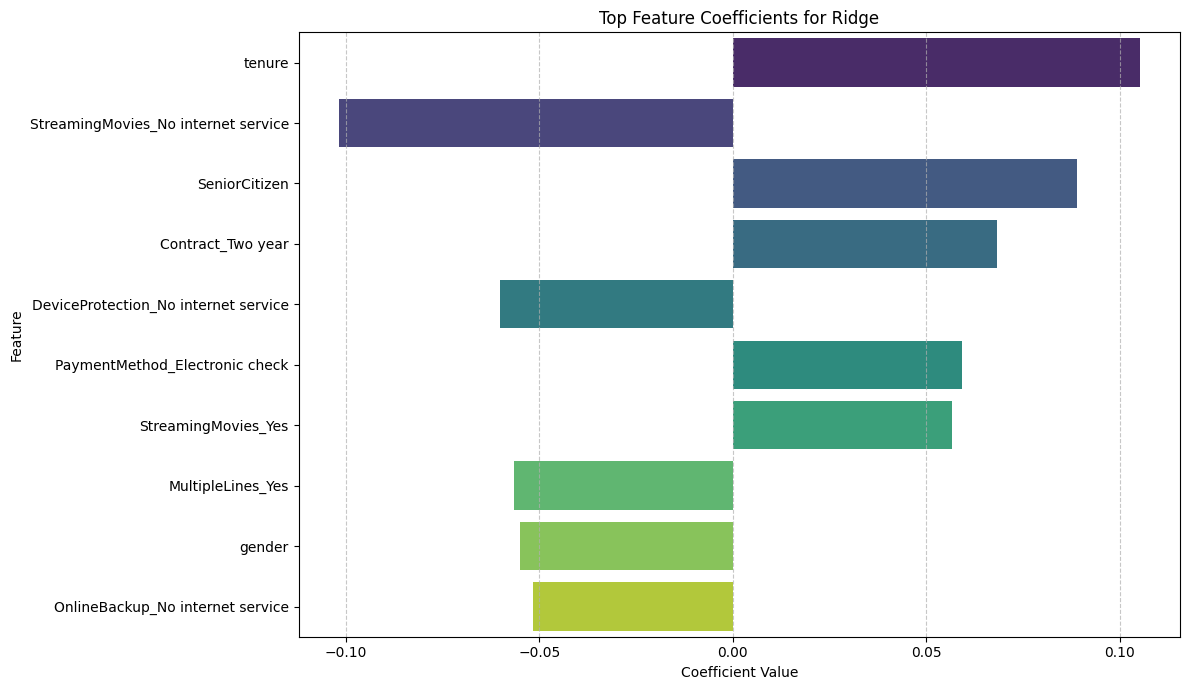


Coefficients for Lasso:


,0
tenure,0.046122
SeniorCitizen,0.000000
gender,-0.000000
Partner,0.000000
Dependents,0.000000
PhoneService,-0.000000
PaperlessBilling,-0.000000
MultipleLines_No phone service,0.000000
MultipleLines_Yes,-0.000000
InternetService_Fiber optic,0.000000


/tmp/ipykernel_40883/1671042303.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients[top_n].values, y=coefficients[top_n].index, palette='viridis')


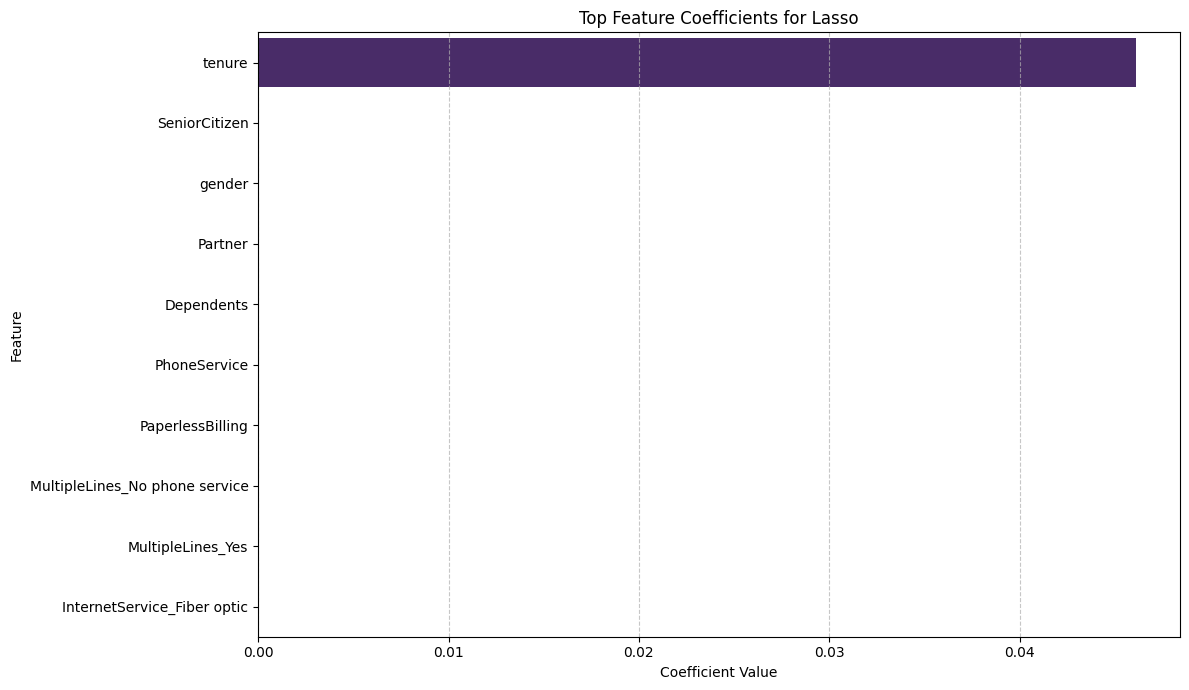


Coefficients for ElasticNet:


,0
tenure,0.055439
SeniorCitizen,0.000000
gender,-0.000000
Partner,0.000000
Dependents,0.000000
PhoneService,-0.000000
PaperlessBilling,-0.000000
MultipleLines_No phone service,0.000000
MultipleLines_Yes,-0.000000
InternetService_Fiber optic,0.000000


/tmp/ipykernel_40883/1671042303.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients[top_n].values, y=coefficients[top_n].index, palette='viridis')


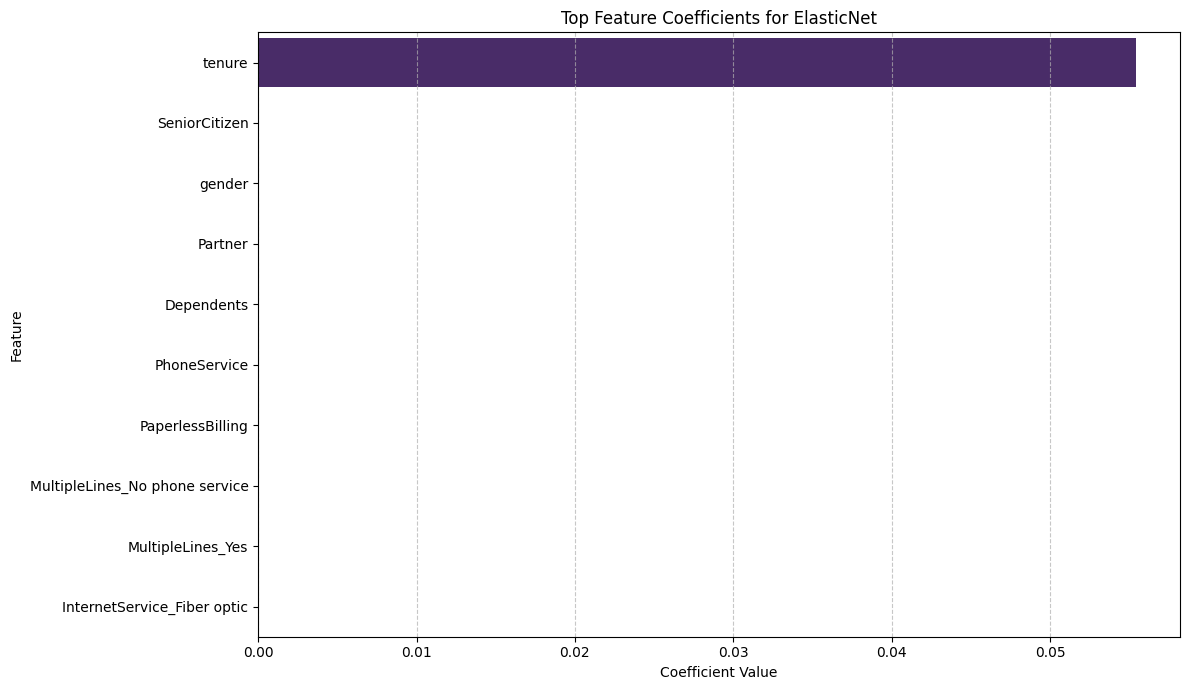


Interpretation of Coefficients:
- Coefficients indicate the strength and direction of the relationship between each feature and the target variable (MonthlyCharges), holding other features constant.
- A positive coefficient means that as the feature value increases, MonthlyCharges tends to increase (and vice-versa for negative coefficients).
- The magnitude of the coefficient indicates the strength of this relationship. For regularized models (Ridge, Lasso, ElasticNet), some coefficients might be shrunk towards zero or exactly zero (Lasso), indicating less importance or feature selection.


In [ ]:
# --- Coefficient Analysis for Linear Models ---
print("\n--- Coefficient Analysis for Linear Models ---")

linear_models = {
    'Linear Regression': best_lin_reg,
    'Ridge': best_ridge,
    'Lasso': best_lasso,
    'ElasticNet': best_elastic_net
}

for name, model in linear_models.items():
    if hasattr(model, 'coef_'):
        print(f"\nCoefficients for {name}:")
        coefficients = pd.Series(model.coef_, index=X_train_reg.columns)
        display(coefficients.sort_values(ascending=False))

        # Plot top N coefficients (e.g., top 10 absolute coefficients)
        plt.figure(figsize=(12, 7))
        abs_coefficients = coefficients.abs().sort_values(ascending=False)
        top_n = abs_coefficients.head(10).index
        sns.barplot(x=coefficients[top_n].values, y=coefficients[top_n].index, palette='viridis')
        plt.title(f'Top Feature Coefficients for {name}')
        plt.xlabel('Coefficient Value')
        plt.ylabel('Feature')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

print("\nInterpretation of Coefficients:")
print("- Coefficients indicate the strength and direction of the relationship between each feature and the target variable (MonthlyCharges), holding other features constant.")
print("- A positive coefficient means that as the feature value increases, MonthlyCharges tends to increase (and vice-versa for negative coefficients).")
print("- The magnitude of the coefficient indicates the strength of this relationship. For regularized models (Ridge, Lasso, ElasticNet), some coefficients might be shrunk towards zero or exactly zero (Lasso), indicating less importance or feature selection.")